# Generative Sparsity Rescue Pipeline
## Can Generative Data Augmentation Rescue Indoor Localization Under Extreme Spatial Sparsity?

**Context:** Our ablation study showed that XGBoost (the best regressor at 0% omission,
MEE = 1.66 m) degrades to ~10 m at 90% location omission. This notebook tests whether
6 generative models (VAE, GAN, DDPM, DIT, Latent DIT, TDPM) can synthesize fill-in
fingerprints to rescue the regressor under high-sparsity conditions.

**Pipeline:**
1. Simulate spatial sparsity via farthest-point thinning (30%, 50%, 70%, 80%, 90%)
2. For each sparsity level → train each generative model on sparse data → generate
   synthetic fingerprints → filter (sparsity mask + KNN gate) → pseudo-label →
   combine with sparse real data → retrain XGBoost → evaluate on fixed test set
3. Compare all 6 tracks (Baseline + 5 augmented) across sparsity levels

**Generative Models:**
| # | Model | Reference |
|---|-------|-----------|
| 1 | VAE | Suroso et al., ECTI-CON 2022 |
| 2 | GAN (WGAN-GP) | Njima et al., IEEE Access 2022 (improved w/ WGAN-GP) |
| 3 | DDPM | Guo et al., CCDC 2023 |
| 4 | DIT | Yan et al., SPIE 2025 |
| 5 | Latent DIT | Proposed — Latent Diffusion Transformer |
| 6 | TDPM | Zhumagali et al., Senior Project 2025 |

## 0 — Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os, sys, platform, copy, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from scipy.spatial.distance import cdist

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import SelectFromModel

import xgboost as xgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import CosineAnnealingLR

# ── macOS fork-safety ────────────────────────────────────────────────
if platform.system() == "Darwin":
    os.environ["OBJC_DISABLE_INITIALIZE_FORK_SAFETY"] = "YES"
    os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
    import multiprocessing
    try:
        multiprocessing.set_start_method("spawn", force=True)
    except RuntimeError:
        pass

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"PyTorch device: {DEVICE}")

# ── Brand colors ─────────────────────────────────────────────────────
C = {
    "teal": "#20808D", "terra": "#A84B2F", "dark_teal": "#1B474D",
    "cyan": "#BCE2E7", "mauve": "#944454", "gold": "#FFC553",
    "olive": "#848456", "brown": "#6E522B",
    "offwhite": "#FCFAF6", "paper": "#F3F3EE", "offblack": "#13343B",
}
CHART_SEQ = [C["teal"], C["terra"], C["dark_teal"], C["mauve"], C["gold"], C["olive"]]

plt.rcParams.update({
    "figure.figsize": (12, 6), "figure.dpi": 150,
    "figure.facecolor": C["offwhite"], "axes.facecolor": C["paper"],
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.labelsize": 11, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": C["offblack"], "text.color": C["offblack"],
    "axes.labelcolor": C["offblack"],
    "xtick.color": C["offblack"], "ytick.color": C["offblack"],
})

PyTorch device: cuda


## 1 — Configuration & Dataset Loading

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/DIT_Localization/preprocessed_data'
    UTSPATH = f'{BASE}/UJIndoorLoc/uj_building2.csv'
    print('Running in Google Colab.')
except ImportError:
    UTSPATH = './uj_building2.csv'
    print('Running locally.')

DATASET_PATH = UTSPATH

OMISSION_PCTS = [0, 10, 30, 50, 70, 80, 90]

# Best kNN hyperparameters from the sparsification study (0% omission, Full track)
KNN_PARAMS = {
    "n_neighbors": 1,
    "weights": "uniform",
    "n_jobs": 1,
}

# Generative model training epochs
# Tuned for CPU feasibility while preserving model quality.
GEN_EPOCHS = 10000          # VAE, GAN, DDPM, DIT
LATENT_DIT_EPOCHS = 10000   # Latent DIT (VAE + DIT stages)
T_DIFFUSION = 1000          # Diffusion timesteps (DDPM, DIT)
T_DIFFUSION_LATENT = 1000   # Latent DIT operates in 64-d space
TDPM_DIFFUSION_STEPS = 100    # TDPM uses far fewer steps (all T iterated per batch)
TDPM_EPOCHS = 5000            # TDPM converges faster due to per-step loss aggregation

# Downstream validation hook frequency (epochs between validations)
VAL_EVERY = 500           # Validation frequency (VAE, GAN, DDPM, DIT, Latent DIT)
TDPM_VAL_EVERY = 500       # TDPM has fewer epochs → validate more often
VAL_N_SAMPLES = 500       # Samples generated per validation probe

# Generative method names (order matters for plotting)
GEN_METHODS = ["VAE", "GAN", "DDPM", "DIT", "Latent DIT", "TDPM"]

# ── Load dataset ─────────────────────────────────────────────────────
df = pd.read_csv(DATASET_PATH)
wap_cols = sorted([c for c in df.columns if c.upper().startswith("WAP")])

if "Pos_x" in df.columns:
    TX, TY, NO_SIGNAL = "Pos_x", "Pos_y", 100
elif "LONGITUDE" in df.columns:
    TX, TY, NO_SIGNAL = "LONGITUDE", "LATITUDE", -105
else:
    raise ValueError("Cannot detect coordinate columns.")

print(f"Loaded {DATASET_PATH}: {len(df)} samples, {len(wap_cols)} WAPs")
print(f"Targets: ({TX}, {TY})  |  No-signal value: {NO_SIGNAL}")

## 2 — Farthest-Point Ordering & Sparsity Simulation

In [ ]:
coords_all = df[[TX, TY]].values
unique_locs = np.unique(coords_all, axis=0)
N_LOCS = len(unique_locs)
print(f"Unique reference locations: {N_LOCS}")

def farthest_point_ordering(locs, seed=42):
    """Return indices into `locs` in farthest-point-sampling order."""
    n = len(locs)
    centroid = locs.mean(axis=0)
    first = np.argmin(np.linalg.norm(locs - centroid, axis=1))
    selected = [first]
    min_dists = np.full(n, np.inf)
    min_dists[first] = -1
    for _ in range(n - 1):
        d = np.linalg.norm(locs - locs[selected[-1]], axis=1)
        min_dists = np.minimum(min_dists, d)
        min_dists[selected] = -1
        nxt = np.argmax(min_dists)
        selected.append(nxt)
        min_dists[nxt] = -1
    return np.array(selected)

fp_order = farthest_point_ordering(unique_locs)
print("Farthest-point ordering computed.")

## 3 — Preprocessing Pipeline

Fixed train/val/test split on full data. Then train & val are filtered
by kept locations; test always uses all data.

In [ ]:
def preprocess_for_rescue(df, wap_cols, tx, ty, no_signal, kept_loc_set, seed=42):
    """
    Build X/y arrays with RSSI normalization to [0,1], fixed test set.
    Returns normalized RSSI and both normalized + raw coordinates.
    """
    X_raw = df[wap_cols].copy()
    y_raw = df[[tx, ty]].values.astype(np.float64)

    # Normalize RSSI: replace no-signal with -105, then scale to [0,1]
    if no_signal == 100:
        X_raw = X_raw.replace(100, -105)
    X_raw = X_raw.values.astype(np.float64)
    # Clip and normalize RSSI to [0, 1] using fixed range [-105, -30]
    X_norm = np.clip((X_raw - (-105)) / (-30 - (-105)), 0, 1)

    # Fixed split indices
    idx_all = np.arange(len(df))
    idx_temp, idx_test = train_test_split(idx_all, test_size=0.20, random_state=seed)
    idx_train, idx_val = train_test_split(idx_temp, test_size=0.25, random_state=seed)

    # Filter train & val by kept locations
    def loc_filter(indices):
        mask = np.array([
            (y_raw[i, 0], y_raw[i, 1]) in kept_loc_set
            for i in indices
        ])
        return indices[mask]

    idx_train = loc_filter(idx_train)
    idx_val = loc_filter(idx_val)

    # Coordinate normalization (fit on train only)
    coord_min = y_raw[idx_train].min(axis=0)
    coord_range = y_raw[idx_train].max(axis=0) - coord_min
    coord_range[coord_range == 0] = 1

    y_train_norm = (y_raw[idx_train] - coord_min) / coord_range
    y_val_norm = (y_raw[idx_val] - coord_min) / coord_range
    y_test_norm = (y_raw[idx_test] - coord_min) / coord_range

    return {
        "X_train": X_norm[idx_train], "X_val": X_norm[idx_val], "X_test": X_norm[idx_test],
        "y_train": y_train_norm, "y_val": y_val_norm, "y_test": y_test_norm,
        "y_train_raw": y_raw[idx_train], "y_val_raw": y_raw[idx_val], "y_test_raw": y_raw[idx_test],
        "coord_min": coord_min, "coord_range": coord_range,
        "n_aps": X_norm.shape[1],
    }

print("Preprocessing function defined.")

## 4 — Generative Model Architectures

All architectures are ported directly from the DIT_406 reference notebook.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# 4a. Shared Components — Sinusoidal PE & EMA
# ══════════════════════════════════════════════════════════════════════

class SinusoidalPE(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -np.log(10000) / (half - 1) * torch.arange(half, device=t.device)
        )
        angles = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)


class TransformerBlock(nn.Module):
    def __init__(self, dim, n_heads=8, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim * 4, dim), nn.Dropout(dropout),
        )

    def forward(self, x):
        h = self.norm1(x)
        h = h.unsqueeze(1) if h.dim() == 2 else h
        attn_out, _ = self.attn(h, h, h)
        attn_out = attn_out.squeeze(1) if x.dim() == 2 else attn_out
        x = x + attn_out
        x = x + self.ffn(self.norm2(x))
        return x


class EMA:
    """Exponential Moving Average of model weights for stable sampling."""
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = copy.deepcopy(model)
        self.shadow.eval()

    def update(self, model):
        with torch.no_grad():
            for s, m in zip(self.shadow.parameters(), model.parameters()):
                s.data.mul_(self.decay).add_(m.data, alpha=1.0 - self.decay)

    def get_model(self):
        return self.shadow


# ══════════════════════════════════════════════════════════════════════
# 4b. VAE (Suroso et al. 2022)
# ══════════════════════════════════════════════════════════════════════

class VAEModel(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_var = nn.Linear(128, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar

    def generate(self, n):
        z = torch.randn(n, self.fc_mu.out_features).to(DEVICE)
        return self.decoder(z).detach()


# ══════════════════════════════════════════════════════════════════════
# 4c. GAN — WGAN-GP (Improved: Wasserstein + Gradient Penalty + Spectral Norm
#      + Minibatch Discrimination)  [fixes mode collapse from vanilla GAN]
# ══════════════════════════════════════════════════════════════════════

class MinibatchDiscrimination(nn.Module):
    """Minibatch discrimination layer to penalise mode collapse."""
    def __init__(self, in_features, out_features=5, kernel_dims=3):
        super().__init__()
        self.T = nn.Parameter(torch.randn(in_features, out_features, kernel_dims) * 0.02)

    def forward(self, x):
        M = torch.mm(x, self.T.view(x.size(1), -1))          # (B, out*kernel)
        M = M.view(x.size(0), -1, self.T.size(2))             # (B, out, kernel)
        diffs = M.unsqueeze(0) - M.unsqueeze(1)                # (B, B, out, kernel)
        abs_diffs = torch.sum(torch.abs(diffs), dim=3)          # (B, B, out)
        exp_diffs = torch.exp(-abs_diffs)                       # (B, B, out)
        mb_feats = exp_diffs.sum(dim=1) - 1                     # (B, out)
        return mb_feats


class Generator(nn.Module):
    """Generator with BatchNorm for improved training stability."""
    def __init__(self, latent_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, output_dim), nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Critic (no sigmoid) with spectral norm + minibatch discrimination for WGAN-GP."""
    def __init__(self, input_dim):
        super().__init__()
        self.main = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(input_dim, 512)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.utils.spectral_norm(nn.Linear(512, 256)),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.mb_disc = MinibatchDiscrimination(256, out_features=5, kernel_dims=3)
        self.output = nn.Linear(256 + 5, 1)  # No sigmoid — Wasserstein critic

    def forward(self, x):
        h = self.main(x)
        mb = self.mb_disc(h)
        return self.output(torch.cat([h, mb], dim=1))


def _gradient_penalty(disc, real, fake, device, gp_weight=10.0):
    """Compute gradient penalty for WGAN-GP."""
    alpha = torch.rand(real.size(0), 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp = disc(interp)
    grads = torch.autograd.grad(outputs=d_interp, inputs=interp,
                                grad_outputs=torch.ones_like(d_interp),
                                create_graph=True, retain_graph=True)[0]
    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp_weight * gp


# ══════════════════════════════════════════════════════════════════════
# 4d. DDPM — flat MLP noise predictor (Guo et al. 2023)
# ══════════════════════════════════════════════════════════════════════

class DDPMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=512):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.time_embed = SinusoidalPE(hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(input_dim + hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )
        # Self-conditioning branch: wider first layer accepts x_t + x0_est + temb
        self.net_sc = nn.Sequential(
            nn.Linear(input_dim * 2 + hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x_t, t):
        temb = self.time_embed(t)
        return self.net(torch.cat([x_t, temb], dim=-1))

    def forward_self_cond(self, x_t, t, x0_est):
        """Self-conditioning: concatenate x0 estimate with x_t before the network."""
        temb = self.time_embed(t)
        return self.net_sc(torch.cat([x_t, x0_est, temb], dim=-1))


# ══════════════════════════════════════════════════════════════════════
# 4e. DIT — Diffusion Transformer (Yan et al. 2025)
# ══════════════════════════════════════════════════════════════════════

class DITModel(nn.Module):
    """Diffusion Transformer that patchifies the input into multiple tokens.

    The 206-dim RSSI vector is split into patches of ``patch_size`` APs,
    each projected to ``hidden_dim``.  Sinusoidal time-embedding is broadcast
    (added) to every token so the transformer can condition on the diffusion
    step.  After the transformer stack the tokens are projected back to their
    original patch sizes and concatenated to reconstruct the full vector.
    """
    def __init__(self, input_dim, hidden_dim=512, n_layers=3, n_heads=8,
                 dropout=0.05, patch_size=16):
        super().__init__()
        self.input_dim = input_dim
        self.patch_size = patch_size
        self.n_patches = int(np.ceil(input_dim / patch_size))
        self.padded_dim = self.n_patches * patch_size  # may need padding

        # Per-patch linear projection
        self.patch_proj = nn.Linear(patch_size, hidden_dim)
        # Self-conditioning patch projection (2x patch width: x_t + x0_est)
        self.patch_proj_sc = nn.Linear(patch_size * 2, hidden_dim)
        # Learnable positional embedding for each patch token
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, hidden_dim) * 0.02)
        # Time embedding (projected to same hidden_dim then added to tokens)
        self.time_embed = SinusoidalPE(hidden_dim)

        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(hidden_dim, n_heads, dropout) for _ in range(n_layers)]
        )
        self.norm_out = nn.LayerNorm(hidden_dim)
        # Project back from hidden_dim to patch_size
        self.unpatch_proj = nn.Linear(hidden_dim, patch_size)

    def _pad_and_patchify(self, x, B):
        """Pad input and reshape to patches."""
        if self.input_dim < self.padded_dim:
            x = nn.functional.pad(x, (0, self.padded_dim - self.input_dim))
        return x.view(B, self.n_patches, self.patch_size)

    def _transformer_and_unpatch(self, h, B):
        """Run transformer blocks and un-patchify."""
        for block in self.transformer_blocks:
            h = block(h)
        h = self.norm_out(h)
        out = self.unpatch_proj(h).view(B, self.padded_dim)
        return out[:, :self.input_dim]

    def forward(self, x_t, t):
        B = x_t.shape[0]
        x_patches = self._pad_and_patchify(x_t, B)
        h = self.patch_proj(x_patches) + self.pos_embed
        temb = self.time_embed(t)
        h = h + temb.unsqueeze(1)
        return self._transformer_and_unpatch(h, B)

    def forward_self_cond(self, x_t, t, x0_est):
        """Self-conditioning: concatenate x0_est patches with x_t patches."""
        B = x_t.shape[0]
        xt_patches = self._pad_and_patchify(x_t, B)
        x0_patches = self._pad_and_patchify(x0_est, B)
        # Concatenate along patch feature dim: (B, n_patches, patch_size*2)
        combined = torch.cat([xt_patches, x0_patches], dim=-1)
        h = self.patch_proj_sc(combined) + self.pos_embed
        temb = self.time_embed(t)
        h = h + temb.unsqueeze(1)
        return self._transformer_and_unpatch(h, B)


# ══════════════════════════════════════════════════════════════════════
# 4f. Latent DIT — VAE Encoder/Decoder + DIT in Latent Space (Proposed)
# ══════════════════════════════════════════════════════════════════════

class LatentVAE(nn.Module):
    """VAE for compressing high-dimensional RSSI to latent space."""
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, 256), nn.ReLU(), nn.BatchNorm1d(256),
        )
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_var = nn.Linear(256, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(), nn.BatchNorm1d(256),
            nn.Linear(256, 512), nn.ReLU(), nn.BatchNorm1d(512),
            nn.Linear(512, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5 * logvar) * torch.randn_like(logvar)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


class LatentDITModel(nn.Module):
    """DIT operating in the latent space of the LatentVAE.

    Patchifies the 64-dim latent vector into 8-dim tokens so the transformer
    attention has a proper sequence to attend over.
    """
    def __init__(self, latent_dim, hidden_dim=256, n_layers=3, n_heads=8,
                 dropout=0.05, patch_size=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.patch_size = patch_size
        self.n_patches = int(np.ceil(latent_dim / patch_size))
        self.padded_dim = self.n_patches * patch_size

        self.patch_proj = nn.Linear(patch_size, hidden_dim)
        # Self-conditioning patch projection (2x patch width: z_t + z0_est)
        self.patch_proj_sc = nn.Linear(patch_size * 2, hidden_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, hidden_dim) * 0.02)
        self.time_embed = SinusoidalPE(hidden_dim)

        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(hidden_dim, n_heads, dropout) for _ in range(n_layers)]
        )
        self.norm_out = nn.LayerNorm(hidden_dim)
        self.unpatch_proj = nn.Linear(hidden_dim, patch_size)

    def _pad_and_patchify(self, z, B):
        """Pad input and reshape to patches."""
        if self.latent_dim < self.padded_dim:
            z = nn.functional.pad(z, (0, self.padded_dim - self.latent_dim))
        return z.view(B, self.n_patches, self.patch_size)

    def _transformer_and_unpatch(self, h, B):
        """Run transformer blocks and un-patchify."""
        for block in self.transformer_blocks:
            h = block(h)
        h = self.norm_out(h)
        out = self.unpatch_proj(h).view(B, self.padded_dim)
        return out[:, :self.latent_dim]

    def forward(self, z_t, t):
        B = z_t.shape[0]
        z_patches = self._pad_and_patchify(z_t, B)
        h = self.patch_proj(z_patches) + self.pos_embed
        temb = self.time_embed(t)
        h = h + temb.unsqueeze(1)
        return self._transformer_and_unpatch(h, B)

    def forward_self_cond(self, z_t, t, z0_est):
        """Self-conditioning: concatenate z0_est patches with z_t patches."""
        B = z_t.shape[0]
        zt_patches = self._pad_and_patchify(z_t, B)
        z0_patches = self._pad_and_patchify(z0_est, B)
        combined = torch.cat([zt_patches, z0_patches], dim=-1)
        h = self.patch_proj_sc(combined) + self.pos_embed
        temb = self.time_embed(t)
        h = h + temb.unsqueeze(1)
        return self._transformer_and_unpatch(h, B)


# ══════════════════════════════════════════════════════════════════════
# 4g. TDPM — Table Diffusion Probabilistic Model (Zhumagali et al. 2025)
#
# Key differences from plain DDPM:
#   - Conditional on (X,Y) spatial coordinates (cDDPM)
#   - Tabular U-Net (encoder-decoder MLP with skip connections)
#   - Cosine beta schedule: β_t = (1 − cos(πt/T)) / 2
#   - Training iterates ALL T diffusion steps per batch (aggregated loss)
#   - Subtractive denoising sampling: x ← x − pred_noise · √β_t
#   - Uses StandardScaler (z-score) normalization for RSSI
# ══════════════════════════════════════════════════════════════════════

import math as _math

def _tdpm_get_beta(t, T):
    """Cosine noise schedule: β_t = (1 − cos(πt/T)) / 2."""
    return (1.0 - _math.cos(_math.pi * t / T)) / 2.0


def _tdpm_timestep_embedding(timesteps, dim):
    """Sinusoidal timestep embedding (same form as SinusoidalPE, functional version)."""
    half = dim // 2
    omega = torch.exp(
        -_math.log(10000) * torch.arange(0, half, device=timesteps.device) / max(half - 1, 1)
    )
    args = timesteps.float().unsqueeze(1) * omega.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2:
        emb = torch.nn.functional.pad(emb, (0, 1))
    return emb


class TabularUNet(nn.Module):
    """Tabular U-Net noise predictor with skip connections.

    Encoder-decoder MLP conditioned on both (X,Y) coordinates and timestep.
    Architecture from Zhumagali et al. (2025).
    """
    def __init__(self, input_dim, cond_dim, time_emb_dim, hidden_dims=None):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [512, 256, 128]

        # Heads for time and condition
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, hidden_dims[0]),
        )
        self.cond_mlp = nn.Sequential(
            nn.Linear(cond_dim, hidden_dims[0]),
            nn.SiLU(),
        )

        # Encoder blocks
        dims_in = [input_dim + hidden_dims[0] * 2] + hidden_dims[:-1]
        self.encoder_blocks = nn.ModuleList(
            nn.Sequential(nn.Linear(in_d, out_d), nn.SiLU())
            for in_d, out_d in zip(dims_in, hidden_dims)
        )

        # Decoder blocks (mirror encoder with skip connections)
        rev = hidden_dims[::-1]
        self.decoder_blocks = nn.ModuleList(
            nn.Sequential(nn.Linear(in_d * 2, out_d), nn.SiLU())
            for in_d, out_d in zip(rev[:-1], rev[1:])
        )

        # Final output layer
        self.output_layer = nn.Linear(hidden_dims[0], input_dim)

    def forward(self, x, cond, t_emb):
        """x: (B, input_dim), cond: (B, cond_dim), t_emb: (B, time_emb_dim)."""
        t_h = self.time_mlp(t_emb)
        c_h = self.cond_mlp(cond)
        h = torch.cat([x, c_h, t_h], dim=1)

        skips = []
        for enc in self.encoder_blocks:
            h = enc(h)
            skips.append(h)
        for dec in self.decoder_blocks:
            skip = skips.pop()
            h = torch.cat([h, skip], dim=1)
            h = dec(h)
        return self.output_layer(h)


class TableDiffusionModel(nn.Module):
    """Conditional Table Diffusion — wraps TabularUNet with timestep embedding."""
    def __init__(self, rss_dim, cond_dim, time_emb_dim=128, hidden_dims=None):
        super().__init__()
        self.time_emb_dim = time_emb_dim
        self.unet = TabularUNet(
            input_dim=rss_dim,
            cond_dim=cond_dim,
            time_emb_dim=time_emb_dim,
            hidden_dims=hidden_dims,
        )

    def forward(self, rss_noised, cond, t):
        t_emb = _tdpm_timestep_embedding(t, self.time_emb_dim)
        return self.unet(rss_noised, cond, t_emb)

    @property
    def rss_dim(self):
        return self.unet.output_layer.out_features


# ══════════════════════════════════════════════════════════════════════
# 4h. DiffusionTrainer — Cosine schedule + self-conditioning + DDIM/full sampling
#
# Key design decisions:
#   1. Cosine noise schedule (Nichol & Dhariwal 2021) — preserves more
#      structure at early timesteps than the linear schedule, which is
#      critical for sparse high-dimensional RSSI data.
#   2. Self-conditioning (Chen et al. 2022) — at each training step the
#      model receives its own x0 prediction from a prior forward pass
#      (with 50 % probability), giving it a "warm start" that greatly
#      accelerates convergence on small datasets.
#   3. Zero terminal SNR — alpha_bar[T-1] is clamped near 0 so the
#      last diffusion step is pure noise, aligning training and
#      inference assumptions.
# ══════════════════════════════════════════════════════════════════════

def _cosine_alpha_bar_schedule(T, s=0.008):
    """Cosine schedule for alpha_bar (Nichol & Dhariwal 2021).

    Returns alpha_bar[0..T-1] where alpha_bar[0] ≈ 1 and alpha_bar[T-1] ≈ 0.
    """
    steps = torch.arange(T + 1, dtype=torch.float64)
    f = torch.cos(((steps / T) + s) / (1 + s) * (np.pi / 2)) ** 2
    alpha_bar = f[1:] / f[0]  # length T
    # Enforce zero terminal SNR: clamp minimum so sqrt doesn't blow up
    alpha_bar = torch.clamp(alpha_bar, min=1e-8, max=0.9999)
    return alpha_bar.float()


class DiffusionTrainer:
    """DDPM trainer with cosine schedule, self-conditioning, and DDIM sampling."""
    def __init__(self, model, input_dim, T=1000, lam=0.0,
                 schedule="cosine", beta_start=1e-4, beta_end=0.02):
        self.model = model
        self.T = T
        self.lam = lam
        self.input_dim = input_dim
        self.self_cond = hasattr(model, 'forward_self_cond')  # auto-detect

        if schedule == "cosine":
            self.alpha_bar = _cosine_alpha_bar_schedule(T).to(DEVICE)
            # Derive betas and alphas from alpha_bar
            self.alphas = torch.ones(T, device=DEVICE)
            self.alphas[0] = self.alpha_bar[0]
            self.alphas[1:] = self.alpha_bar[1:] / self.alpha_bar[:-1]
            self.betas = (1.0 - self.alphas).clamp(min=1e-8, max=0.999)
        else:  # linear (legacy fallback)
            self.betas = torch.linspace(beta_start, beta_end, T).to(DEVICE)
            self.alphas = (1.0 - self.betas).to(DEVICE)
            self.alpha_bar = torch.cumprod(self.alphas, dim=0).to(DEVICE)

        self.sqrt_alpha_bar = torch.sqrt(self.alpha_bar)
        self.sqrt_one_minus_alpha_bar = torch.sqrt(1.0 - self.alpha_bar)

    def _q_sample(self, r0, t, noise):
        """Forward diffusion: q(r_t | r_0)."""
        sqrt_ab = self.sqrt_alpha_bar[t].unsqueeze(-1)
        sqrt_omab = self.sqrt_one_minus_alpha_bar[t].unsqueeze(-1)
        return sqrt_ab * r0 + sqrt_omab * noise

    def train_step(self, r0, optimizer):
        t = torch.randint(0, self.T, (r0.shape[0],), device=DEVICE)
        noise = torch.randn_like(r0)
        r_t = self._q_sample(r0, t, noise)

        # ── Self-conditioning (Chen et al. 2022) ────────────────────
        # With 50% probability, first compute a no-grad x0 estimate and
        # feed it back to the model as an extra conditioning signal.
        if self.self_cond and torch.rand(1).item() > 0.5:
            with torch.no_grad():
                x0_est = self._predict_x0(r_t, t, self.model(r_t, t))
            noise_pred = self.model.forward_self_cond(r_t, t, x0_est)
        else:
            noise_pred = self.model(r_t, t)

        mse_loss = nn.functional.mse_loss(noise_pred, noise)
        kl_loss = torch.mean((noise_pred.var(dim=0) - noise.var(dim=0)) ** 2)
        loss = mse_loss + self.lam * kl_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
        optimizer.step()
        return loss.item()

    def _predict_x0(self, x_t, t, noise_pred):
        """Estimate x0 from x_t and predicted noise."""
        sqrt_ab = self.sqrt_alpha_bar[t].unsqueeze(-1)
        sqrt_omab = self.sqrt_one_minus_alpha_bar[t].unsqueeze(-1)
        return (x_t - sqrt_omab * noise_pred) / sqrt_ab.clamp(min=1e-6)

    def _model_forward(self, x, t_batch, x0_prev=None):
        """Unified model call: uses self-conditioning when available."""
        if self.self_cond and x0_prev is not None:
            return self.model.forward_self_cond(x, t_batch, x0_prev)
        return self.model(x, t_batch)

    @torch.no_grad()
    def sample_ddim(self, n_samples, ddim_steps=50, eta=0.3):
        self.model.eval()
        step_size = max(1, self.T // ddim_steps)
        timesteps = list(reversed(range(0, self.T, step_size)))

        x = torch.randn(n_samples, self.input_dim, device=DEVICE)
        x0_prev = torch.zeros_like(x)  # self-cond init

        for i in range(len(timesteps)):
            t = timesteps[i]
            t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
            noise_pred = self._model_forward(x, t_batch, x0_prev)
            alpha_bar_t = self.alpha_bar[t]

            x0_pred = (x - torch.sqrt(1 - alpha_bar_t) * noise_pred) / torch.sqrt(alpha_bar_t).clamp(min=1e-6)
            x0_pred = torch.clamp(x0_pred, -5, 5)
            x0_prev = x0_pred  # carry forward for next step

            if i < len(timesteps) - 1:
                t_prev = timesteps[i + 1]
                alpha_bar_prev = self.alpha_bar[t_prev]
                sigma = eta * torch.sqrt(
                    (1 - alpha_bar_prev) / (1 - alpha_bar_t).clamp(min=1e-8)
                    * (1 - alpha_bar_t / alpha_bar_prev).clamp(min=0)
                )
                dir_xt = torch.sqrt(torch.clamp(1 - alpha_bar_prev - sigma**2, min=0)) * noise_pred
                x = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt
                if sigma > 0:
                    x = x + sigma * torch.randn_like(x)
            else:
                x = x0_pred

        self.model.train()
        return x

    @torch.no_grad()
    def sample_ddpm_full(self, n_samples):
        """Full DDPM ancestral sampling — all T steps. Best quality."""
        self.model.eval()
        x = torch.randn(n_samples, self.input_dim, device=DEVICE)
        x0_prev = torch.zeros_like(x)  # self-cond init

        for t in reversed(range(self.T)):
            t_batch = torch.full((n_samples,), t, device=DEVICE, dtype=torch.long)
            noise_pred = self._model_forward(x, t_batch, x0_prev)
            alpha_t = self.alphas[t]
            alpha_bar_t = self.alpha_bar[t]
            beta_t = self.betas[t]
            # Update x0 estimate for self-conditioning
            x0_prev = self._predict_x0(x, t_batch, noise_pred)
            # Reverse-process mean
            coeff = beta_t / torch.sqrt(1.0 - alpha_bar_t).clamp(min=1e-6)
            mean = (x - coeff * noise_pred) / torch.sqrt(alpha_t).clamp(min=1e-6)
            if t > 0:
                sigma = torch.sqrt(beta_t)
                x = mean + sigma * torch.randn_like(x)
            else:
                x = mean
        self.model.train()
        return x

    @torch.no_grad()
    def sample(self, n_samples):
        # Use full ancestral sampling for small T (fast enough), DDIM for large T
        if self.T <= 300:
            return self.sample_ddpm_full(n_samples)
        return self.sample_ddim(n_samples, ddim_steps=50, eta=0.3)


print("All generative model architectures defined.")

## 5 — Quality Filtering: Sparsity Mask + KNN Gate

Ported from DIT_406 with restored thresholds.

In [ ]:
def apply_sparsity_mask(fake_rssi_norm, real_rssi_norm):
    """Make fake AP activation pattern match real data distribution."""
    real_counts = (real_rssi_norm > 0.01).sum(axis=1)
    mean_k = real_counts.mean()
    std_k = real_counts.std()
    min_k = max(3, int(real_counts.min()))
    max_k = int(np.percentile(real_counts, 95))

    fake_out = fake_rssi_norm.copy()
    n_aps = fake_rssi_norm.shape[1]

    for i in range(len(fake_out)):
        k = int(np.clip(np.random.normal(mean_k, std_k), min_k, max_k))
        top_k_idx = np.argsort(fake_out[i])[-k:]
        mask = np.zeros(n_aps, dtype=bool)
        mask[top_k_idx] = True
        fake_out[i, ~mask] = 0.0

    return fake_out


def knn_quality_gate(fake_rssi, real_rssi, k=5, percentile_threshold=90, n_sub=500):
    """KNN quality gate: reject out-of-distribution fake samples."""
    n_sub = min(n_sub, len(real_rssi))
    real_sub = real_rssi[np.random.choice(len(real_rssi), n_sub, replace=False)]

    # Real-to-real: skip self-distance
    rr_dists = cdist(real_sub, real_rssi, metric="euclidean")
    rr_knn = np.array([np.sort(rr_dists[i])[1:k+1].mean() for i in range(n_sub)])
    threshold = np.percentile(rr_knn, percentile_threshold)

    # Fake-to-real
    fr_dists = cdist(fake_rssi, real_rssi, metric="euclidean")
    fr_knn = np.array([np.sort(fr_dists[i])[:k].mean() for i in range(len(fake_rssi))])

    mask = fr_knn < threshold
    print(f"    KNN gate: threshold={threshold:.3f}, kept {mask.sum()}/{len(mask)} ({100*mask.mean():.0f}%)")
    return fake_rssi[mask], mask


def filter_synthetic(fake_raw, real_train, n_target):
    """Full quality filtering pipeline: clip → sparsity mask → KNN gate → cap."""
    fake = np.clip(fake_raw, 0, 1)
    fake = apply_sparsity_mask(fake, real_train)
    fake, _ = knn_quality_gate(fake, real_train, k=5, percentile_threshold=90)

    if len(fake) < 10:
        print(f"    WARNING: Only {len(fake)} samples passed QC.")
        return None

    if len(fake) > n_target:
        fake = fake[:n_target]

    return fake


print("Quality filtering functions defined.")

## 6 — Pseudo-Labelling with kNN

We train a kNN regressor on the sparse real data, then use it
to assign (x, y) pseudo-labels to the filtered synthetic fingerprints.

In [ ]:
def train_knn_regressor(X_train, y_train, params=None):
    """Train the tuned kNN regressor (fixed hyperparameters, no HPO)."""
    if params is None:
        params = KNN_PARAMS.copy()
    mdl = KNeighborsRegressor(**params)
    mdl.fit(X_train, y_train)
    return mdl


def pseudo_label_with_knn(knn_model, fake_rssi):
    """Assign coordinate pseudo-labels to synthetic fingerprints."""
    return knn_model.predict(fake_rssi)


def mee_meters(y_true_norm, y_pred_norm, coord_min, coord_range):
    """Compute Mean Euclidean Error in meters."""
    yt = y_true_norm * coord_range + coord_min
    yp = y_pred_norm * coord_range + coord_min
    return np.sqrt(((yt - yp) ** 2).sum(axis=1))


print("kNN regressor and pseudo-labelling functions defined.")

## 7 — Generative Training Functions

Each function trains a generative model from scratch on the sparse training data
and returns raw synthetic samples (before quality filtering).

In [ ]:
def downstream_val_mee(fake_raw, X_train, y_train, X_val, y_val,
                       coord_min, coord_range, knn_base, n_target):
    """
    Downstream validation hook: measure how well the generative model's
    current output rescues kNN on the held-out validation set.

    Steps:
      1. Quality-filter the raw synthetic samples (clip → sparsity mask → KNN gate)
      2. Pseudo-label the survivors with knn_base
      3. Retrain XGBoost on (sparse_real + synthetic)
      4. Evaluate MEE on validation set → return scalar error (meters)

    Returns float('inf') if too few samples pass quality control.
    """
    fake = np.clip(fake_raw, 0, 1)
    fake = apply_sparsity_mask(fake, X_train)
    fake, _ = knn_quality_gate(fake, X_train, k=5, percentile_threshold=90)

    if len(fake) < 10:
        return float("inf")

    if len(fake) > n_target:
        fake = fake[:n_target]

    pseudo = pseudo_label_with_knn(knn_base, fake)
    X_comb = np.vstack([X_train, fake])
    y_comb = np.vstack([y_train, pseudo])

    mdl = train_knn_regressor(X_comb, y_comb)
    pred_val = mdl.predict(X_val)
    dists = mee_meters(y_val, pred_val, coord_min, coord_range)
    return float(dists.mean())


def train_and_generate_vae(X_train, n_aps, n_generate, epochs=2000,
                           X_val=None, y_val=None, y_train=None,
                           coord_min=None, coord_range=None,
                           knn_base=None, val_every=50, n_val_samples=500):
    """Train VAE with downstream validation hook & best-checkpoint restoration."""
    print(f"    Training VAE ({epochs} epochs, val_every={val_every})...")
    model = VAEModel(n_aps).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    train_tensor = torch.FloatTensor(X_train).to(DEVICE)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(epochs):
        model.train()
        for i in range(0, len(X_train), 128):
            batch = train_tensor[i:i+128]
            recon, mu, lv = model(batch)
            kl = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch.shape[0]
            loss = nn.functional.mse_loss(recon, batch) + 0.001 * kl
            opt.zero_grad(); loss.backward(); opt.step()

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            model.eval()
            with torch.no_grad():
                probe = model.generate(n_val_samples).cpu().numpy()
            cur_mee = downstream_val_mee(
                probe, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_state = copy.deepcopy(model.state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 200 == 0:
            print(f"      VAE epoch {ep+1}/{epochs}")

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"      ✓ Restored best VAE weights (val MEE: {best_mee:.2f} m)")

    model.eval()
    with torch.no_grad():
        fake = model.generate(n_generate).cpu().numpy()
    return fake, history


def train_and_generate_gan(X_train, n_aps, n_generate, epochs=2000,
                           X_val=None, y_val=None, y_train=None,
                           coord_min=None, coord_range=None,
                           knn_base=None, val_every=50, n_val_samples=500):
    """Train WGAN-GP with spectral norm + minibatch discrimination.

    Uses Wasserstein loss with gradient penalty (λ=10) instead of vanilla
    BCE, n_critic=5 critic updates per generator step, and minibatch
    discrimination to prevent mode collapse.
    """
    print(f"    Training WGAN-GP ({epochs} epochs, val_every={val_every})...")
    latent_dim = 128
    n_critic = 3  # critic updates per generator step

    gen = Generator(latent_dim, n_aps).to(DEVICE)
    disc = Discriminator(n_aps).to(DEVICE)
    opt_g = optim.Adam(gen.parameters(), lr=1e-4, betas=(0.5, 0.9))
    opt_d = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.9))
    train_tensor = torch.FloatTensor(X_train).to(DEVICE)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_gen_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(epochs):
        gen.train(); disc.train()
        for i in range(0, len(X_train), 128):
            batch = train_tensor[i:i+128]; bs = batch.shape[0]

            # ── Train critic n_critic times ──
            for _ in range(n_critic):
                z = torch.randn(bs, latent_dim, device=DEVICE)
                fake_data = gen(z).detach()
                d_real = disc(batch).mean()
                d_fake = disc(fake_data).mean()
                gp = _gradient_penalty(disc, batch, fake_data, DEVICE)
                d_loss = d_fake - d_real + gp
                opt_d.zero_grad(); d_loss.backward(); opt_d.step()

            # ── Train generator ──
            z = torch.randn(bs, latent_dim, device=DEVICE)
            g_loss = -disc(gen(z)).mean()
            opt_g.zero_grad(); g_loss.backward(); opt_g.step()

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            gen.eval()
            with torch.no_grad():
                z = torch.randn(n_val_samples, latent_dim, device=DEVICE)
                probe = gen(z).cpu().numpy()
            cur_mee = downstream_val_mee(
                probe, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_gen_state = copy.deepcopy(gen.state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 200 == 0:
            print(f"      WGAN-GP epoch {ep+1}/{epochs}")

    # Restore best checkpoint
    if best_gen_state is not None:
        gen.load_state_dict(best_gen_state)
        print(f"      ✓ Restored best Generator weights (val MEE: {best_mee:.2f} m)")

    gen.eval()
    with torch.no_grad():
        z = torch.randn(n_generate, latent_dim, device=DEVICE)
        fake = gen(z).cpu().numpy()
    return fake, history


def train_and_generate_ddpm(X_train, n_aps, n_generate, epochs=2000, T=1000,
                            X_val=None, y_val=None, y_train=None,
                            coord_min=None, coord_range=None,
                            knn_base=None, val_every=50, n_val_samples=500):
    """Train DDPM with downstream validation hook & best-checkpoint restoration.

    Key: RSSI data is z-score standardized before diffusion training so that
    the data distribution is approximately N(0,1), which aligns with the
    Gaussian noise assumptions of the DDPM forward/reverse process.
    Samples are inverse-transformed back to [0,1] RSSI scale after generation.
    """
    from sklearn.preprocessing import StandardScaler as _StdScaler

    print(f"    Training DDPM ({epochs} epochs, T={T}, val_every={val_every})...")

    # ── Z-score standardize RSSI so data ≈ N(0,1) for diffusion ──────
    scaler = _StdScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    model = DDPMModel(n_aps, hidden_dim=512).to(DEVICE)
    trainer = DiffusionTrainer(model, n_aps, T=T, lam=0.0)
    opt = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    train_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)
    dl = DataLoader(TensorDataset(train_tensor), batch_size=128, shuffle=True,
                    num_workers=0, pin_memory=False)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(epochs):
        model.train()
        for (batch,) in dl:
            trainer.train_step(batch, opt)

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            with torch.no_grad():
                probe_scaled = trainer.sample(n_val_samples).cpu().numpy()
            probe = scaler.inverse_transform(probe_scaled)
            probe = np.clip(probe, 0, 1)
            cur_mee = downstream_val_mee(
                probe, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_state = copy.deepcopy(model.state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 200 == 0:
            print(f"      DDPM epoch {ep+1}/{epochs}")

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        # Re-wrap in DiffusionTrainer for sampling (inherits cosine schedule)
        trainer = DiffusionTrainer(model, n_aps, T=T, lam=0.0)
        print(f"      ✓ Restored best DDPM weights (val MEE: {best_mee:.2f} m)")

    with torch.no_grad():
        fake_scaled = trainer.sample(n_generate).cpu().numpy()
    fake = scaler.inverse_transform(fake_scaled)
    fake = np.clip(fake, 0, 1)
    return fake, history


def train_and_generate_dit(X_train, n_aps, n_generate, epochs=2000, T=1000,
                           X_val=None, y_val=None, y_train=None,
                           coord_min=None, coord_range=None,
                           knn_base=None, val_every=50, n_val_samples=500):
    """Train DIT with downstream validation hook & best-checkpoint restoration.

    Key: RSSI data is z-score standardized before diffusion training so that
    the data distribution is approximately N(0,1), which aligns with the
    Gaussian noise assumptions of the DIT diffusion forward/reverse process.
    Samples are inverse-transformed back to [0,1] RSSI scale after generation.
    """
    from sklearn.preprocessing import StandardScaler as _StdScaler

    print(f"    Training DIT ({epochs} epochs, T={T}, val_every={val_every})...")

    # ── Z-score standardize RSSI so data ≈ N(0,1) for diffusion ──────
    scaler = _StdScaler()
    X_train_scaled = scaler.fit_transform(X_train)

    dit_model = DITModel(n_aps, hidden_dim=512, n_layers=3, n_heads=8, dropout=0.05).to(DEVICE)
    diffusion = DiffusionTrainer(dit_model, n_aps, T=T, lam=0.0)
    optimizer = optim.AdamW(dit_model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    ema = EMA(dit_model, decay=0.999)

    train_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)
    dl = DataLoader(TensorDataset(train_tensor), batch_size=128, shuffle=True,
                    num_workers=0, pin_memory=False)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_dit_state = None
    best_ema_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(epochs):
        dit_model.train()
        for (batch,) in dl:
            diffusion.train_step(batch, optimizer)
        ema.update(dit_model)
        scheduler.step()

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            ema_model = ema.get_model()
            tmp_sampler = DiffusionTrainer(ema_model, n_aps, T=T)
            for attr in ["betas", "alphas", "alpha_bar", "sqrt_alpha_bar", "sqrt_one_minus_alpha_bar"]:
                setattr(tmp_sampler, attr, getattr(diffusion, attr))
            with torch.no_grad():
                probe_scaled = tmp_sampler.sample(n_val_samples).cpu().numpy()
            probe = scaler.inverse_transform(probe_scaled)
            probe = np.clip(probe, 0, 1)
            cur_mee = downstream_val_mee(
                probe, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_dit_state = copy.deepcopy(dit_model.state_dict())
                best_ema_state = copy.deepcopy(ema.get_model().state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 200 == 0:
            print(f"      DIT epoch {ep+1}/{epochs}")

    # Restore best checkpoint (prefer EMA weights for sampling)
    if best_ema_state is not None:
        ema_model_final = copy.deepcopy(dit_model)
        ema_model_final.load_state_dict(best_ema_state)
        ema_model_final.eval()
        print(f"      ✓ Restored best DIT/EMA weights (val MEE: {best_mee:.2f} m)")
    else:
        ema_model_final = ema.get_model()

    sampler = DiffusionTrainer(ema_model_final, n_aps, T=T)
    for attr in ["betas", "alphas", "alpha_bar", "sqrt_alpha_bar", "sqrt_one_minus_alpha_bar"]:
        setattr(sampler, attr, getattr(diffusion, attr))

    with torch.no_grad():
        fake_scaled = sampler.sample(n_generate).cpu().numpy()
    fake = scaler.inverse_transform(fake_scaled)
    fake = np.clip(fake, 0, 1)
    return fake, history


def train_and_generate_latent_dit(X_train, n_aps, n_generate,
                                   vae_epochs=1000, dit_epochs=2000, T=1000,
                                   X_val=None, y_val=None, y_train=None,
                                   coord_min=None, coord_range=None,
                                   knn_base=None, val_every=50, n_val_samples=500):
    """Train Latent DIT with downstream validation hook & best-checkpoint restoration.

    Stage 1 (VAE) trains without validation (autoencoder loss is sufficient).
    Stage 2 (DIT in latent space) uses the downstream hook to checkpoint.

    Key: VAE latent codes are z-score standardized before diffusion training so
    the latent distribution is approximately N(0,1), aligning with the Gaussian
    noise assumptions of the diffusion forward/reverse process.  Samples are
    inverse-transformed back to the original latent scale before VAE decoding.
    """
    from sklearn.preprocessing import StandardScaler as _StdScaler
    print(f"    Training Latent DIT (VAE: {vae_epochs} ep, DIT: {dit_epochs} ep, "
          f"T={T}, val_every={val_every})...")
    latent_dim = 64
    train_tensor = torch.FloatTensor(X_train).to(DEVICE)

    # ── Stage 1: Train the Latent VAE (no downstream hook needed) ─────
    vae = LatentVAE(n_aps, latent_dim=latent_dim).to(DEVICE)
    vae_opt = optim.Adam(vae.parameters(), lr=1e-3)

    for ep in range(vae_epochs):
        vae.train()
        for i in range(0, len(X_train), 128):
            batch = train_tensor[i:i+128]
            recon, mu, lv = vae(batch)
            recon_loss = nn.functional.mse_loss(recon, batch)
            kl_loss = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / batch.shape[0]
            loss = recon_loss + 0.001 * kl_loss
            vae_opt.zero_grad(); loss.backward(); vae_opt.step()
        if (ep + 1) % 200 == 0:
            print(f"      Latent VAE epoch {ep+1}/{vae_epochs}")

    # Encode training data to latent space
    vae.eval()
    with torch.no_grad():
        mu_all, _ = vae.encode(train_tensor)
    Z_train_raw = mu_all.detach().cpu().numpy()

    # ── Z-score standardize latent codes so data ≈ N(0,1) for diffusion ──
    z_scaler = _StdScaler()
    Z_train_scaled = z_scaler.fit_transform(Z_train_raw)
    Z_train = torch.FloatTensor(Z_train_scaled).to(DEVICE)

    # ── Stage 2: Train DIT in latent space (with downstream hook) ─────
    ldit = LatentDITModel(latent_dim, hidden_dim=256, n_layers=3, n_heads=8, dropout=0.05).to(DEVICE)
    ldit_diff = DiffusionTrainer(ldit, latent_dim, T=T, lam=0.0)
    ldit_opt = optim.AdamW(ldit.parameters(), lr=2e-4, weight_decay=1e-4)
    ldit_scheduler = CosineAnnealingLR(ldit_opt, T_max=dit_epochs, eta_min=1e-6)
    ldit_ema = EMA(ldit, decay=0.999)

    ldl = DataLoader(TensorDataset(Z_train), batch_size=128, shuffle=True,
                     num_workers=0, pin_memory=False)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_ldit_state = None
    best_ema_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(dit_epochs):
        ldit.train()
        for (batch,) in ldl:
            ldit_diff.train_step(batch, ldit_opt)
        ldit_ema.update(ldit)
        ldit_scheduler.step()

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            ema_ldit_tmp = ldit_ema.get_model()
            tmp_sampler = DiffusionTrainer(ema_ldit_tmp, latent_dim, T=T)
            for attr in ["betas", "alphas", "alpha_bar", "sqrt_alpha_bar", "sqrt_one_minus_alpha_bar"]:
                setattr(tmp_sampler, attr, getattr(ldit_diff, attr))
            with torch.no_grad():
                z_probe_scaled = tmp_sampler.sample(n_val_samples).cpu().numpy()
                z_probe_orig = z_scaler.inverse_transform(z_probe_scaled)
                z_probe_tensor = torch.FloatTensor(z_probe_orig).to(DEVICE)
                probe = vae.decode(z_probe_tensor).cpu().numpy()
            probe = np.clip(probe, 0, 1)
            cur_mee = downstream_val_mee(
                probe, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_ldit_state = copy.deepcopy(ldit.state_dict())
                best_ema_state = copy.deepcopy(ldit_ema.get_model().state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 200 == 0:
            print(f"      Latent DIT epoch {ep+1}/{dit_epochs}")

    # Restore best checkpoint
    if best_ema_state is not None:
        ema_ldit_final = copy.deepcopy(ldit)
        ema_ldit_final.load_state_dict(best_ema_state)
        ema_ldit_final.eval()
        print(f"      ✓ Restored best Latent DIT/EMA weights (val MEE: {best_mee:.2f} m)")
    else:
        ema_ldit_final = ldit_ema.get_model()

    ldit_sampler = DiffusionTrainer(ema_ldit_final, latent_dim, T=T)
    for attr in ["betas", "alphas", "alpha_bar", "sqrt_alpha_bar", "sqrt_one_minus_alpha_bar"]:
        setattr(ldit_sampler, attr, getattr(ldit_diff, attr))

    with torch.no_grad():
        z_fake_scaled = ldit_sampler.sample(n_generate).cpu().numpy()
    z_fake_orig = z_scaler.inverse_transform(z_fake_scaled)
    z_fake_tensor = torch.FloatTensor(z_fake_orig).to(DEVICE)
    with torch.no_grad():
        fake = vae.decode(z_fake_tensor).cpu().numpy()
    fake = np.clip(fake, 0, 1)
    return fake, history


def _tdpm_sample(model, cond_tensor, rss_dim, T):
    """TDPM reverse sampling: x_t = x_t - pred_noise * sqrt(beta_t), t = T-1 down to 0."""
    model.eval()
    n = cond_tensor.shape[0]
    samples = torch.randn(n, rss_dim, device=DEVICE)
    with torch.no_grad():
        for t in reversed(range(T)):
            beta = _tdpm_get_beta(t, T)
            t_vec = torch.full((n,), t, dtype=torch.long, device=DEVICE)
            pred_noise = model(samples, cond_tensor, t_vec)
            samples = samples - pred_noise * np.sqrt(beta)
    return samples


def train_and_generate_tdpm(X_train, n_aps, n_generate, epochs=200, T=100,
                             X_val=None, y_val=None, y_train=None,
                             coord_min=None, coord_range=None,
                             knn_base=None, val_every=20, n_val_samples=500):
    """Train TDPM (Zhumagali et al. 2025) with downstream validation hook.

    TDPM is a conditional cDDPM that generates RSSI fingerprints conditioned on
    (X,Y) coordinates. Key differences from other models in this pipeline:
      - Conditional on spatial coordinates (not unconditional)
      - Uses StandardScaler (z-score) normalization internally
      - Iterates ALL T diffusion steps per batch (aggregated MSE loss)
      - Subtractive denoising at sampling: x <- x - pred * sqrt(beta_t)
      - Fewer diffusion steps (typically 5-100) and fewer epochs (70-200)
    """
    from sklearn.preprocessing import StandardScaler as _StdScaler

    print(f"    Training TDPM ({epochs} epochs, T={T}, val_every={val_every})...")

    # ── Build condition tensor from pseudo-labels ─────────────────────
    # TDPM needs (X,Y) conditions. Use the raw training coords.
    # The y_train are normalized coords — convert to raw for conditioning.
    y_train_raw_coords = y_train * coord_range + coord_min  # (N, 2) in metres
    cond_train = torch.FloatTensor(y_train_raw_coords).to(DEVICE)

    # ── Z-score normalize RSSI (TDPM-specific) ───────────────────────
    scaler = _StdScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    rss_tensor = torch.FloatTensor(X_train_scaled).to(DEVICE)

    # ── Instantiate model ─────────────────────────────────────────────
    rss_dim = n_aps
    model = TableDiffusionModel(
        rss_dim=rss_dim, cond_dim=2, time_emb_dim=128,
        hidden_dims=[512, 256, 128],
    ).to(DEVICE)
    opt = optim.Adam(model.parameters(), lr=6e-4)
    mse_fn = nn.MSELoss()

    dataset = TensorDataset(cond_train, rss_tensor)
    dl = DataLoader(dataset, batch_size=64, shuffle=True,
                    num_workers=0, pin_memory=False)

    can_validate = (X_val is not None and knn_base is not None)
    best_mee = None
    best_state = None
    n_target = max(50, n_generate // 2)
    history = {"epochs": [], "errors": []}

    for ep in range(epochs):
        model.train()
        for cond_batch, rss_batch in dl:
            loss_accum = 0.0
            for t_step in range(T):
                beta = _tdpm_get_beta(t_step, T)
                noise = torch.randn_like(rss_batch) * np.sqrt(beta)
                noised = rss_batch + noise
                t_vec = torch.full((rss_batch.size(0),), t_step,
                                   dtype=torch.long, device=DEVICE)
                pred = model(noised, cond_batch, t_vec)
                loss_accum += mse_fn(pred, noise)
            loss = loss_accum / T
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        # ── Downstream validation hook ──
        if can_validate and (ep + 1) % val_every == 0:
            # Generate probe conditioned on the training positions
            n_probe = min(n_val_samples, len(cond_train))
            probe_idx = np.random.choice(len(cond_train), n_probe, replace=False)
            cond_probe = cond_train[probe_idx]

            probe_scaled = _tdpm_sample(model, cond_probe, rss_dim, T).cpu().numpy()
            probe_rssi = scaler.inverse_transform(probe_scaled)
            # Clip to [0,1] range (our pipeline's normalization)
            probe_rssi = np.clip(probe_rssi, 0, 1)

            cur_mee = downstream_val_mee(
                probe_rssi, X_train, y_train, X_val, y_val,
                coord_min, coord_range, knn_base, n_target)
            history["epochs"].append(ep + 1)
            history["errors"].append(cur_mee)
            if best_mee is None or cur_mee < best_mee:
                best_mee = cur_mee
                best_state = copy.deepcopy(model.state_dict())
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  ★ New Best")
            else:
                print(f"      [Epoch {ep+1}] Val MEE: {cur_mee:.2f} m  (best: {best_mee:.2f} m)")
        elif (ep + 1) % 50 == 0:
            print(f"      TDPM epoch {ep+1}/{epochs}")

    # Restore best checkpoint
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"      ✓ Restored best TDPM weights (val MEE: {best_mee:.2f} m)")

    # ── Generate final synthetic samples ─────────────────────────────
    # We need n_generate samples. Condition on the training positions
    # (sample with replacement to reach n_generate).
    model.eval()
    gen_idx = np.random.choice(len(cond_train), n_generate, replace=True)
    cond_gen = cond_train[gen_idx]

    fake_scaled = _tdpm_sample(model, cond_gen, rss_dim, T).cpu().numpy()
    fake = scaler.inverse_transform(fake_scaled)
    # Clip to [0,1] to match pipeline's RSSI normalization
    fake = np.clip(fake, 0, 1)

    return fake, history


# Dispatch table for clean loop
# Each generator returns (fake_samples, history_dict)
# The `ctx` dict carries validation context from the main loop.
GENERATORS = {
    "VAE": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_vae(
        Xtr, naps, ngen, epochs=ep, **ctx),
    "GAN": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_gan(
        Xtr, naps, ngen, epochs=ep, **ctx),
    "DDPM": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_ddpm(
        Xtr, naps, ngen, epochs=ep, T=T, **ctx),
    "DIT": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_dit(
        Xtr, naps, ngen, epochs=ep, T=T, **ctx),
    "Latent DIT": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_latent_dit(
        Xtr, naps, ngen, vae_epochs=ep // 2, dit_epochs=ep, T=T, **ctx),
    "TDPM": lambda Xtr, naps, ngen, ep, T, ctx: train_and_generate_tdpm(
        Xtr, naps, ngen, epochs=ep, T=T,
        **{**ctx, "val_every": TDPM_VAL_EVERY}),
}

print("All generative training functions defined.")

## 8 — Main Experiment Loop

For each omission level:
1. Simulate sparsity (farthest-point thinning)
2. Train baseline XGBoost on sparse data → record MEE
3. For each generative model: train → generate → filter → pseudo-label →
   combine with sparse data → retrain XGBoost → record MEE

In [ ]:
# ── Results storage ──────────────────────────────────────────────────
# Structure: RESULTS[method][pct] = {"mee": float, "dists": array}
RESULTS = {}
for method in ["Baseline"] + GEN_METHODS:
    RESULTS[method] = {}

# Error trajectory storage: HISTORIES[method][pct] = {"epochs": [...], "errors": [...]}
HISTORIES = {}
for method in GEN_METHODS:
    HISTORIES[method] = {}

# Synthetic data storage for visualization:
# SYNTH_DATA[method][pct] = {"fake_rssi": array, "pseudo_xy": array}
# REAL_DATA_PER_LEVEL[pct] = {"X_train": array, "y_train_raw": array, "coord_min", "coord_range"}
SYNTH_DATA = {}
for method in GEN_METHODS:
    SYNTH_DATA[method] = {}
REAL_DATA_PER_LEVEL = {}

# Target total training size = what we'd have at 0% omission
# (compute from full data split)
idx_all = np.arange(len(df))
idx_temp_full, _ = train_test_split(idx_all, test_size=0.20, random_state=SEED)
idx_train_full, _ = train_test_split(idx_temp_full, test_size=0.25, random_state=SEED)
FULL_TRAIN_SIZE = len(idx_train_full)
print(f"Full training set size (0% omission): {FULL_TRAIN_SIZE}")

t_total_start = time.time()

for pct in OMISSION_PCTS:
    t_level_start = time.time()
    n_keep = max(1, int(N_LOCS * (1 - pct / 100)))
    kept_idx = fp_order[:n_keep]
    kept_locs = unique_locs[kept_idx]
    kept_set = set(map(tuple, kept_locs.tolist()))

    print(f"\n{'═' * 70}")
    print(f"  OMISSION = {pct}%  │  Keeping {n_keep}/{N_LOCS} locations")
    print(f"{'═' * 70}")

    # Preprocess with sparsity
    data = preprocess_for_rescue(df, wap_cols, TX, TY, NO_SIGNAL, kept_set, seed=SEED)
    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val   = data["X_val"]
    y_val   = data["y_val"]
    X_test  = data["X_test"]
    y_test  = data["y_test"]
    coord_min = data["coord_min"]
    coord_range = data["coord_range"]
    n_aps = data["n_aps"]

    print(f"  Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]} | APs: {n_aps}")

    # Store real training data for visualization
    REAL_DATA_PER_LEVEL[pct] = {
        "X_train": X_train,
        "y_train_raw": data["y_train_raw"],
        "coord_min": coord_min,
        "coord_range": coord_range,
    }

    if X_train.shape[0] < 10:
        print("  ⚠ Not enough training samples. Skipping.")
        continue

    # ── Track 1: Baseline (no augmentation) ──────────────────────────
    print(f"\n  ── Baseline kNN (no augmentation) ──")
    knn_base = train_knn_regressor(X_train, y_train)
    pred_base = knn_base.predict(X_test)
    dists_base = mee_meters(y_test, pred_base, coord_min, coord_range)
    mee_base = dists_base.mean()
    RESULTS["Baseline"][pct] = {"mee": mee_base, "dists": dists_base}
    print(f"  Baseline MEE = {mee_base:.3f} m (n_train={X_train.shape[0]})")

    # ── Tracks 2-7: Generative Augmentation ──────────────────────────
    n_synthetic_target = max(50, FULL_TRAIN_SIZE - X_train.shape[0])
    n_generate_raw = n_synthetic_target * 2  # Over-generate for filtering

    for method in GEN_METHODS:
        print(f"\n  ── {method} Augmentation ──")
        t_gen_start = time.time()

        # Determine epochs and diffusion steps per model
        if method == "Latent DIT":
            gen_ep = LATENT_DIT_EPOCHS
        elif method == "TDPM":
            gen_ep = TDPM_EPOCHS
        else:
            gen_ep = GEN_EPOCHS

        # Build validation context dict for the downstream hook
        val_ctx = {
            "X_val": X_val, "y_val": y_val, "y_train": y_train,
            "coord_min": coord_min, "coord_range": coord_range,
            "knn_base": knn_base,
            "val_every": VAL_EVERY, "n_val_samples": VAL_N_SAMPLES,
        }

        # Select diffusion steps per model family
        if method == "TDPM":
            t_diff = TDPM_DIFFUSION_STEPS
        elif method == "Latent DIT":
            t_diff = T_DIFFUSION_LATENT
        else:
            t_diff = T_DIFFUSION

        # Train generative model and generate raw samples
        try:
            fake_raw, hist = GENERATORS[method](
                X_train, n_aps, n_generate_raw, gen_ep, t_diff, val_ctx
            )
            HISTORIES[method][pct] = hist
        except Exception as e:
            print(f"    ERROR training {method}: {e}")
            RESULTS[method][pct] = {"mee": mee_base, "dists": dists_base}
            HISTORIES[method][pct] = {"epochs": [], "errors": []}
            continue

        # Quality filtering
        fake_filtered = filter_synthetic(fake_raw, X_train, n_synthetic_target)

        if fake_filtered is None or len(fake_filtered) < 10:
            print(f"    Too few samples passed QC. Using baseline.")
            RESULTS[method][pct] = {"mee": mee_base, "dists": dists_base}
            continue

        # Pseudo-label with the baseline XGBoost
        pseudo_labels = pseudo_label_with_knn(knn_base, fake_filtered)

        # Store synthetic data for visualization
        # Convert pseudo-labels back to meters for the floorplan scatter
        pseudo_xy_meters = pseudo_labels * coord_range + coord_min
        SYNTH_DATA[method][pct] = {
            "fake_rssi": fake_filtered.copy(),
            "pseudo_xy": pseudo_xy_meters.copy(),
        }

        # Combine sparse real + synthetic
        X_combined = np.vstack([X_train, fake_filtered])
        y_combined = np.vstack([y_train, pseudo_labels])
        print(f"    Combined dataset: {X_combined.shape[0]} samples "
              f"(real={X_train.shape[0]}, synth={fake_filtered.shape[0]})")

        # Retrain kNN on combined data
        knn_aug = train_knn_regressor(X_combined, y_combined)
        pred_aug = knn_aug.predict(X_test)
        dists_aug = mee_meters(y_test, pred_aug, coord_min, coord_range)
        mee_aug = dists_aug.mean()

        RESULTS[method][pct] = {"mee": mee_aug, "dists": dists_aug}

        delta = mee_aug - mee_base
        direction = "↓ improvement" if delta < 0 else "↑ worse"
        print(f"    {method} MEE = {mee_aug:.3f} m ({direction}: {abs(delta):.3f} m)")
        print(f"    Time: {(time.time() - t_gen_start) / 60:.1f} min")

    print(f"\n  Level {pct}% completed in {(time.time() - t_level_start) / 60:.1f} min")

print(f"\n{'═' * 70}")
print(f"  ALL LEVELS COMPLETE — Total time: {(time.time() - t_total_start) / 60:.1f} min")
print(f"{'═' * 70}")

Full training set size (0% omission): 837

══════════════════════════════════════════════════════════════════════
  OMISSION = 0%  │  Keeping 79/79 locations
══════════════════════════════════════════════════════════════════════
  Train: 837 | Val: 279 | Test: 280 | APs: 190

  ── Baseline kNN (no augmentation) ──
  Baseline MEE = 1.126 m (n_train=837)

  ── VAE Augmentation ──
    Training VAE (10000 epochs, val_every=500)...
      VAE epoch 200/10000
      VAE epoch 400/10000
    KNN gate: threshold=0.645, kept 405/500 (81%)
      [Epoch 500] Val MEE: 1.59 m  ★ New Best
      VAE epoch 600/10000
      VAE epoch 800/10000
    KNN gate: threshold=0.655, kept 411/500 (82%)
      [Epoch 1000] Val MEE: 1.61 m  (best: 1.59 m)
      VAE epoch 1200/10000
      VAE epoch 1400/10000
    KNN gate: threshold=0.652, kept 412/500 (82%)
      [Epoch 1500] Val MEE: 1.55 m  ★ New Best
      VAE epoch 1600/10000
      VAE epoch 1800/10000
    KNN gate: threshold=0.645, kept 406/500 (81%)
      [Epoch 

## 9 — Results Table

In [ ]:
print("\n═══ Results Summary: MEE (m) at Each Sparsity Level ═══\n")

rows = []
for method in ["Baseline"] + GEN_METHODS:
    for pct in OMISSION_PCTS:
        if pct in RESULTS[method]:
            r = RESULTS[method][pct]
            rows.append({
                "Omit %": pct,
                "Method": method,
                "MEE (m)": round(r["mee"], 3),
                "P50 (m)": round(np.median(r["dists"]), 3),
                "P90 (m)": round(np.percentile(r["dists"], 90), 3),
            })

results_df = pd.DataFrame(rows)
print(results_df.to_markdown(index=False))

# Save results to JSON (without numpy arrays)
export = {}
for method in ["Baseline"] + GEN_METHODS:
    for pct in OMISSION_PCTS:
        if pct in RESULTS[method]:
            r = RESULTS[method][pct]
            key = f"{pct}|{method}"
            export[key] = {
                "mee": round(r["mee"], 4),
                "p50": round(float(np.median(r["dists"])), 4),
                "p90": round(float(np.percentile(r["dists"], 90)), 4),
            }

# Include error trajectories
export["_histories"] = {}
for method in GEN_METHODS:
    for pct in OMISSION_PCTS:
        if pct in HISTORIES[method] and HISTORIES[method][pct]["epochs"]:
            key = f"{pct}|{method}"
            export["_histories"][key] = {
                "epochs": HISTORIES[method][pct]["epochs"],
                "errors": [round(e, 4) for e in HISTORIES[method][pct]["errors"]],
            }

with open("generative_rescue_results.json", "w") as f:
    json.dump(export, f, indent=2)
print("\n✓ Results exported to generative_rescue_results.json")


═══ Results Summary: MEE (m) at Each Sparsity Level ═══

|   Omit % | Method     |   MEE (m) |   P50 (m) |   P90 (m) |
|---------:|:-----------|----------:|----------:|----------:|
|        0 | Baseline   |     1.126 |     0     |     1.057 |
|       10 | Baseline   |     1.513 |     0     |     4.419 |
|       30 | Baseline   |     3.321 |     0     |    10.682 |
|       50 | Baseline   |     5.059 |     2.11  |    13.366 |
|       70 | Baseline   |     9.26  |    10.182 |    18.246 |
|       80 | Baseline   |    12.315 |    11.317 |    21.476 |
|       90 | Baseline   |    20.38  |    20.828 |    33.976 |
|        0 | VAE        |     1.321 |     0     |     3.513 |
|       10 | VAE        |     1.823 |     0     |     5.029 |
|       30 | VAE        |     3.7   |     0     |    11.994 |
|       50 | VAE        |     5.29  |     2.11  |    14.861 |
|       70 | VAE        |     9.763 |    10.209 |    19.895 |
|       80 | VAE        |    13.085 |    11.918 |    21.567 |
|       90 |

## 10 — Plot 1: Sparsity Rescue Curve

Line chart: MEE vs. Omission % for all 6 tracks (Baseline + 5 generative).

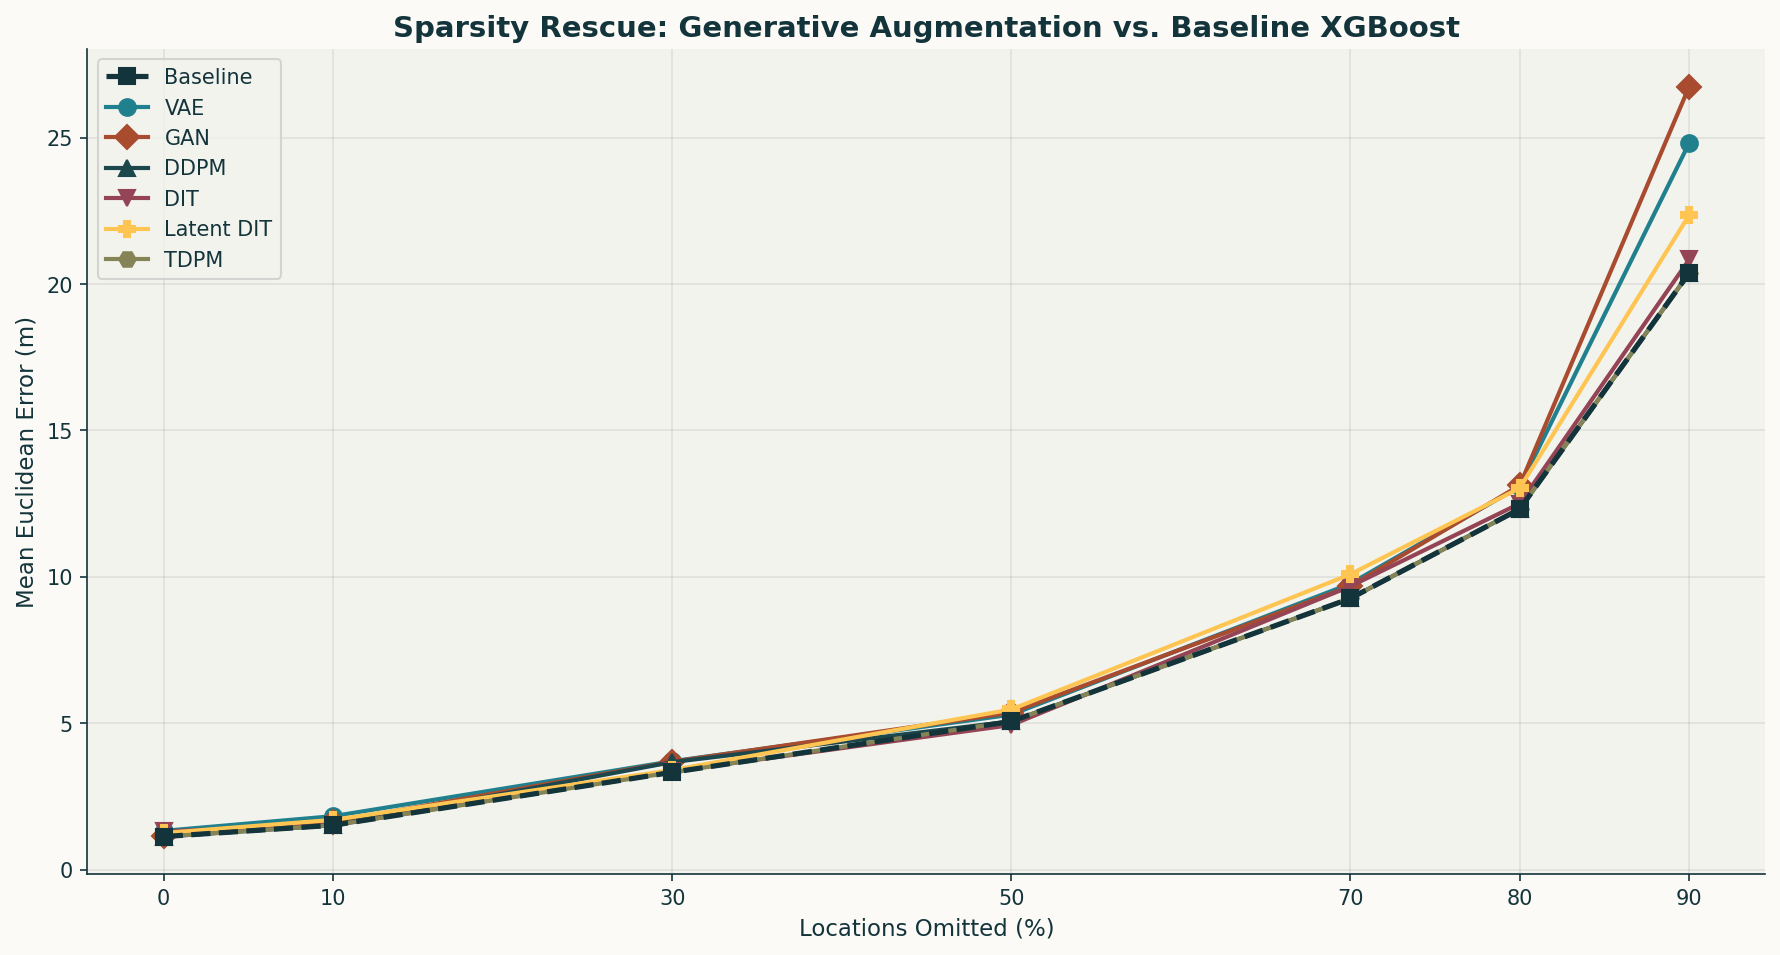

✓ Sparsity rescue curve saved.


In [ ]:
METHOD_COLORS = {
    "Baseline": C["offblack"],
    "VAE": C["teal"],
    "GAN": C["terra"],
    "DDPM": C["dark_teal"],
    "DIT": C["mauve"],
    "Latent DIT": C["gold"],
    "TDPM": C["olive"],
}
METHOD_MARKERS = {
    "Baseline": "s",
    "VAE": "o",
    "GAN": "D",
    "DDPM": "^",
    "DIT": "v",
    "Latent DIT": "P",
    "TDPM": "H",
}

fig, ax = plt.subplots(figsize=(12, 6.5))

for method in ["Baseline"] + GEN_METHODS:
    pcts_plot, mees_plot = [], []
    for pct in OMISSION_PCTS:
        if pct in RESULTS[method]:
            pcts_plot.append(pct)
            mees_plot.append(RESULTS[method][pct]["mee"])

    ls = "--" if method == "Baseline" else "-"
    lw = 2.5 if method == "Baseline" else 2.0
    ax.plot(pcts_plot, mees_plot, ls, color=METHOD_COLORS[method],
            marker=METHOD_MARKERS[method], markersize=8, linewidth=lw,
            label=method, zorder=3 if method == "Baseline" else 2)

ax.set_xlabel("Locations Omitted (%)")
ax.set_ylabel("Mean Euclidean Error (m)")
ax.set_title("Sparsity Rescue: Generative Augmentation vs. Baseline XGBoost")
ax.legend(frameon=True, fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(OMISSION_PCTS)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rescue_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Sparsity rescue curve saved.")

## 11 — Plot 2: Augmentation Delta Bar Charts

One subplot per omission level. Grouped bars showing absolute MEE
for Baseline vs. each generative method.

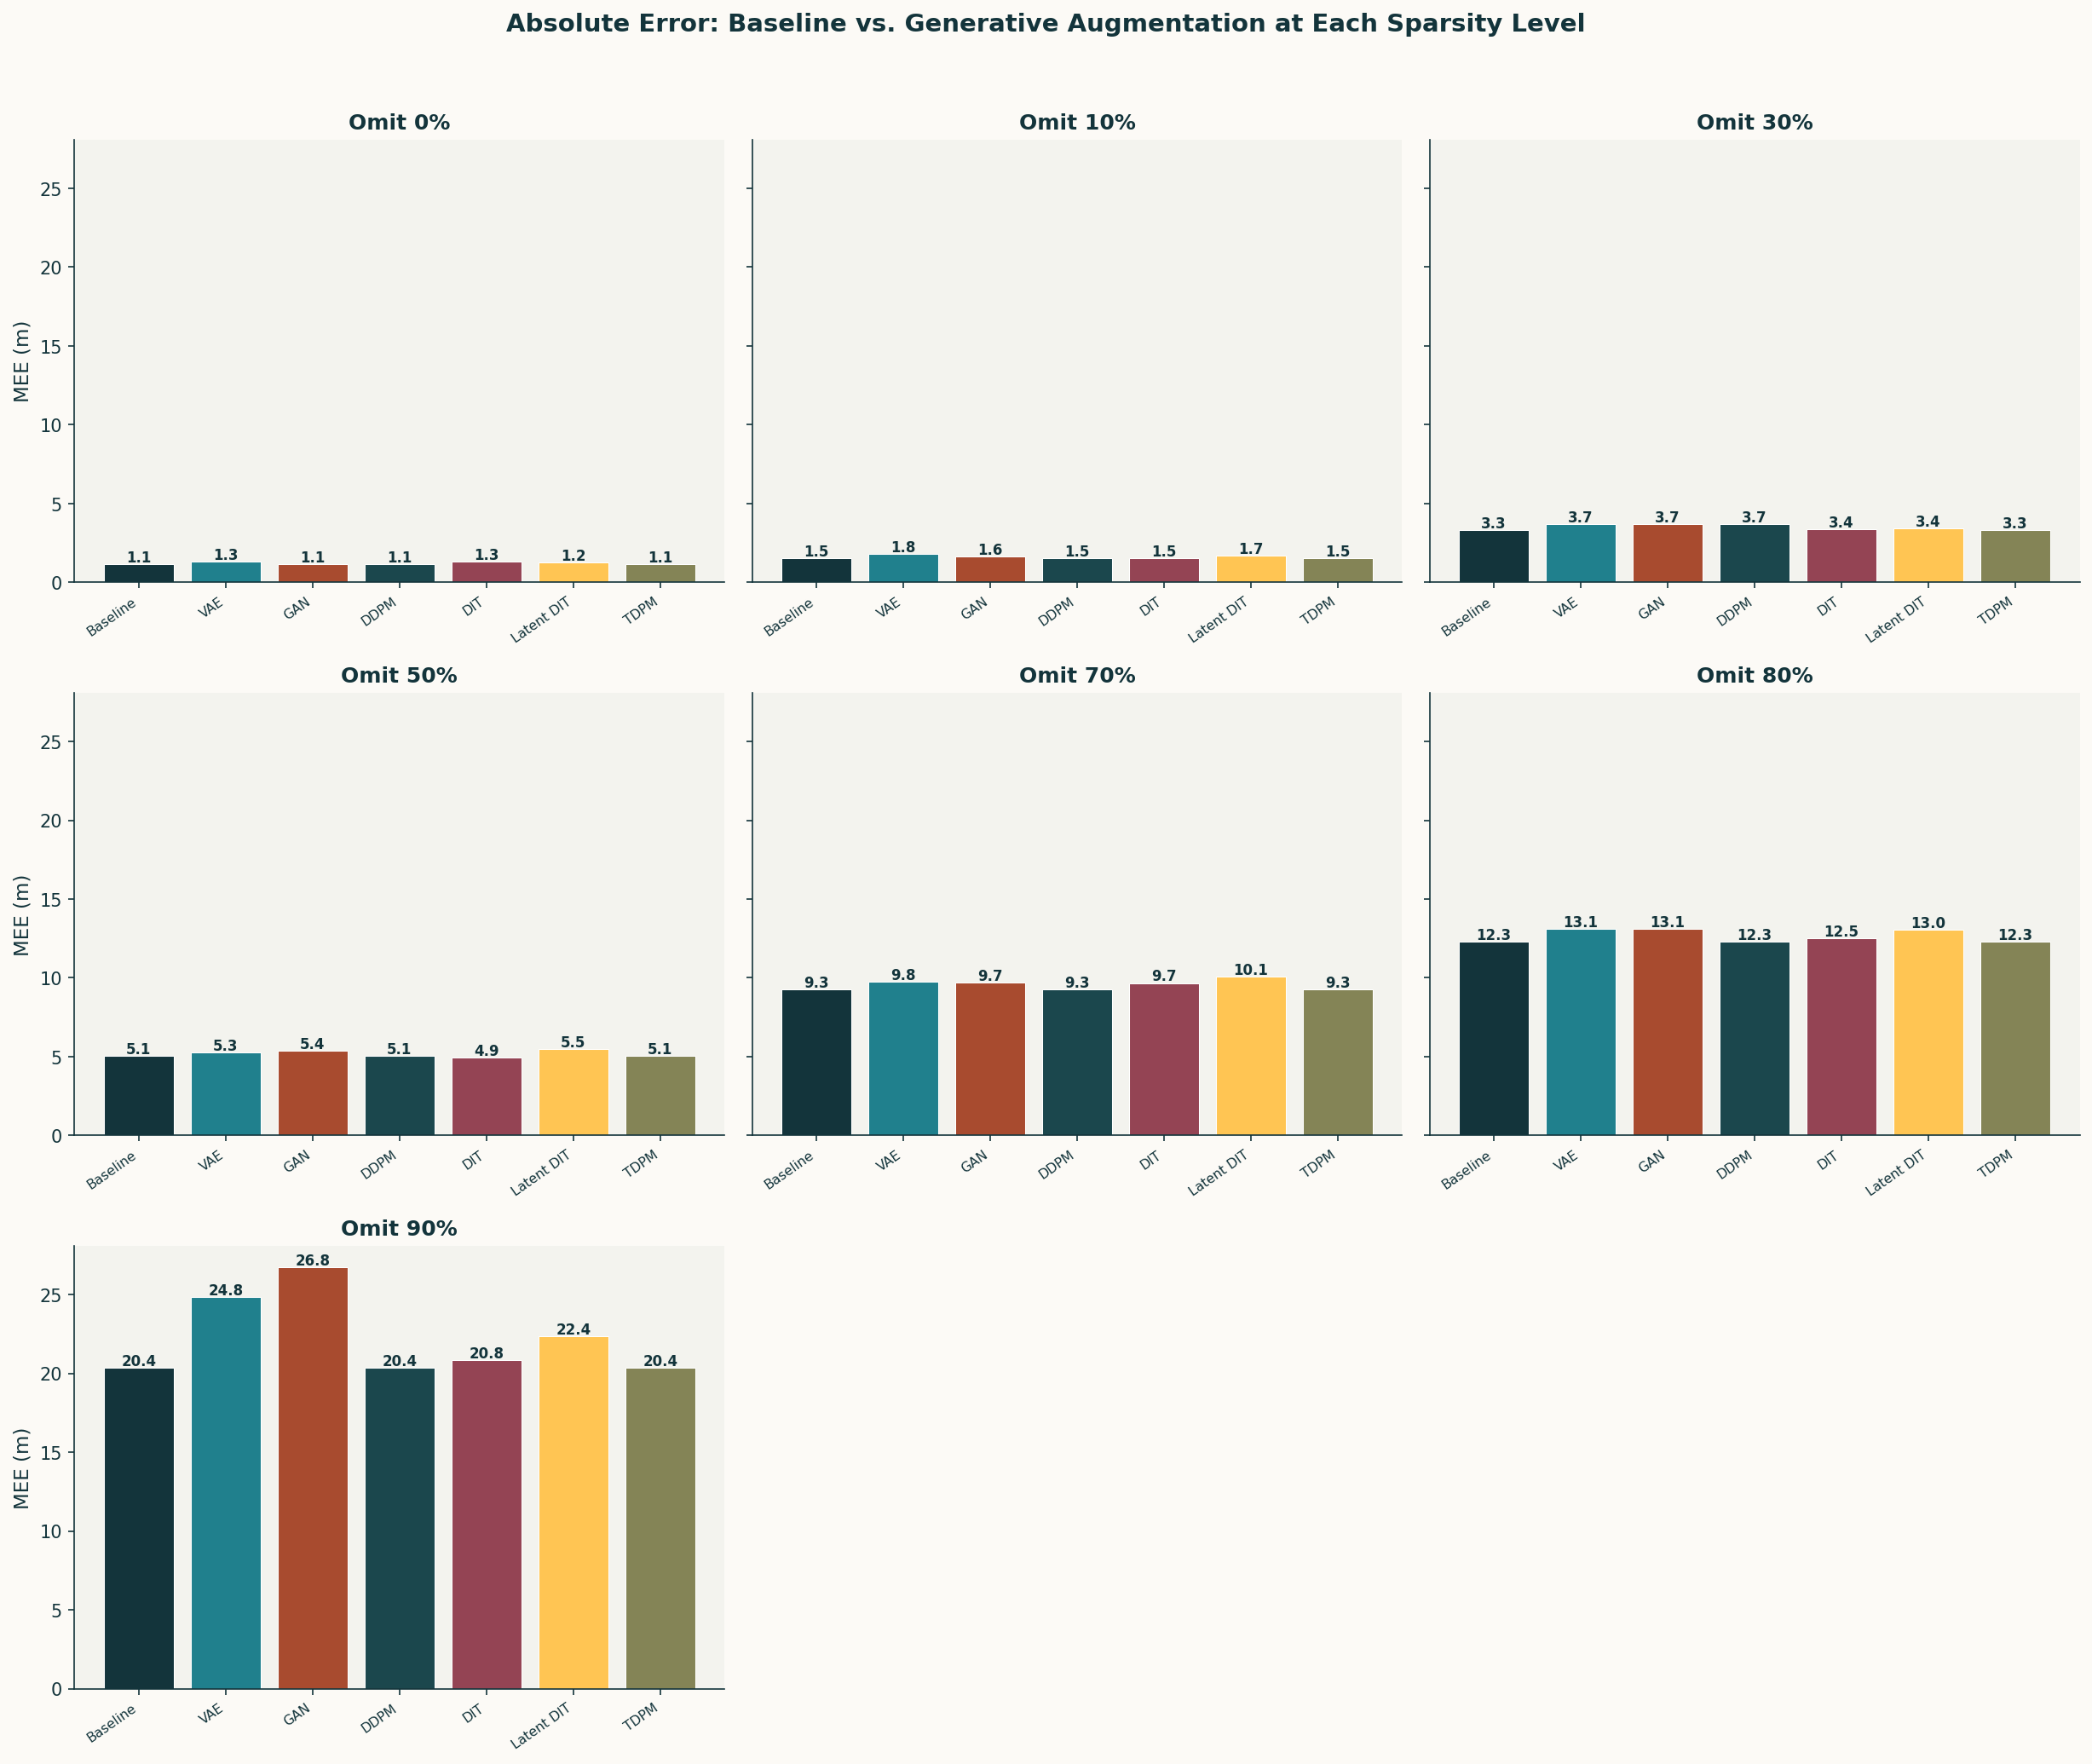

✓ Augmentation delta bar charts saved.


In [ ]:
n_bar_levels = len(OMISSION_PCTS)
n_bar_cols = min(3, n_bar_levels)
n_bar_rows = int(np.ceil(n_bar_levels / n_bar_cols))

fig, axes = plt.subplots(n_bar_rows, n_bar_cols,
                         figsize=(5.5 * n_bar_cols, 4.5 * n_bar_rows),
                         sharey=True)
if n_bar_levels == 1:
    axes = np.array([axes])
axes_flat = axes.flatten()

all_methods = ["Baseline"] + GEN_METHODS
bar_colors = [METHOD_COLORS[m] for m in all_methods]

for idx, pct in enumerate(OMISSION_PCTS):
    ax = axes_flat[idx]
    mees = []
    for method in all_methods:
        if pct in RESULTS[method]:
            mees.append(RESULTS[method][pct]["mee"])
        else:
            mees.append(np.nan)

    x = np.arange(len(all_methods))
    bars = ax.bar(x, mees, color=bar_colors, edgecolor="white", linewidth=0.5)

    # Value labels on bars
    for xi, val in enumerate(mees):
        if not np.isnan(val):
            ax.text(xi, val + 0.15, f"{val:.1f}", ha="center",
                    fontsize=8, fontweight="bold", color=C["offblack"])

    ax.set_xticks(x)
    ax.set_xticklabels(all_methods, fontsize=7.5, rotation=35, ha="right")
    ax.set_title(f"Omit {pct}%", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if idx % n_bar_cols == 0:
        ax.set_ylabel("MEE (m)")

# Hide unused subplots
for j in range(idx + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Absolute Error: Baseline vs. Generative Augmentation at Each Sparsity Level",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("rescue_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Augmentation delta bar charts saved.")

## 12 — Plot 3: Improvement Heatmap

Heatmap showing the absolute MEE improvement (negative = better) of each
generative method over the baseline at each sparsity level.

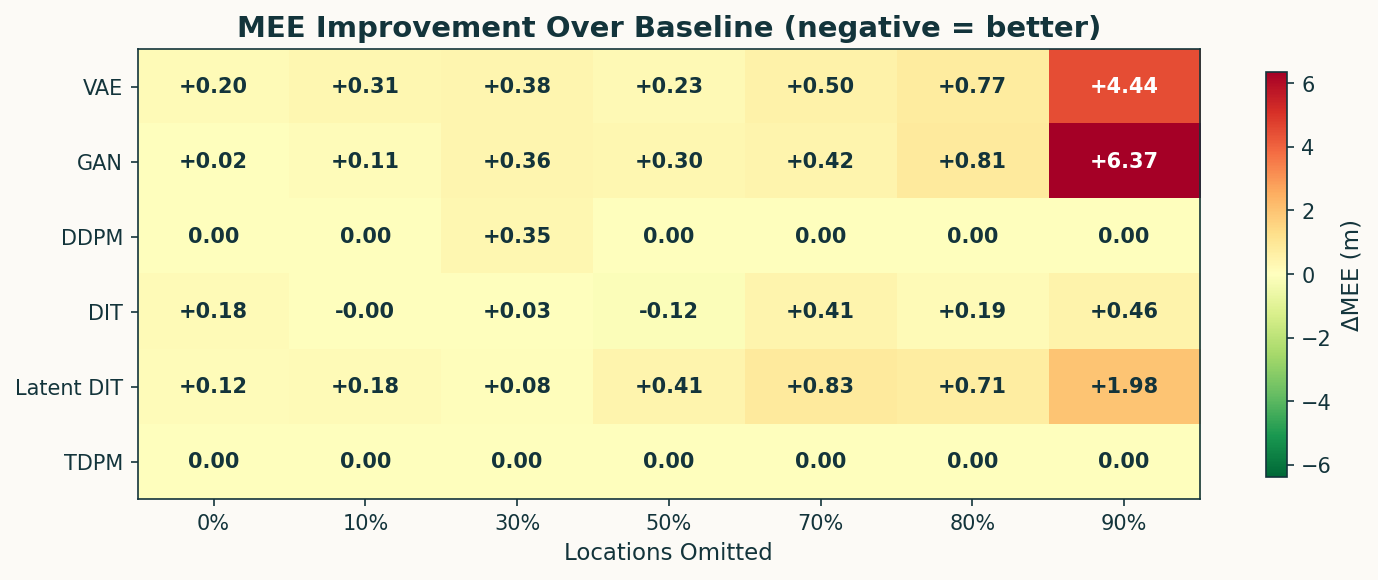

✓ Improvement heatmap saved.


In [ ]:
heat_data = []
for method in GEN_METHODS:
    row = []
    for pct in OMISSION_PCTS:
        if pct in RESULTS[method] and pct in RESULTS["Baseline"]:
            delta = RESULTS[method][pct]["mee"] - RESULTS["Baseline"][pct]["mee"]
            row.append(round(delta, 3))
        else:
            row.append(np.nan)
    heat_data.append(row)

heat_df = pd.DataFrame(heat_data, index=GEN_METHODS,
                       columns=[f"{p}%" for p in OMISSION_PCTS])

fig, ax = plt.subplots(figsize=(10, 4))
vmax = max(abs(heat_df.min().min()), abs(heat_df.max().max()))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
im = ax.imshow(heat_df.values, cmap="RdYlGn_r", aspect="auto", norm=norm)

ax.set_xticks(range(len(OMISSION_PCTS)))
ax.set_xticklabels([f"{p}%" for p in OMISSION_PCTS])
ax.set_yticks(range(len(GEN_METHODS)))
ax.set_yticklabels(GEN_METHODS)
ax.set_xlabel("Locations Omitted")
ax.set_title("MEE Improvement Over Baseline (negative = better)", fontweight="bold")

# Annotate cells
for i in range(len(GEN_METHODS)):
    for j in range(len(OMISSION_PCTS)):
        val = heat_df.values[i, j]
        if not np.isnan(val):
            sign = "+" if val > 0 else ""
            text_color = "white" if abs(val) > vmax * 0.6 else C["offblack"]
            ax.text(j, i, f"{sign}{val:.2f}", ha="center", va="center",
                    fontsize=10, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="ΔMEE (m)", shrink=0.9)
plt.tight_layout()
plt.savefig("rescue_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Improvement heatmap saved.")

## 12b — Plot 4: Downstream Error Trajectory

Convergence curves showing how each generative model’s downstream
validation MEE evolves during training. One subplot per sparsity level.
This visualizes the benefit of the downstream validation hook —
models that converge and then oscillate upward are checkpointed at
their minimum.

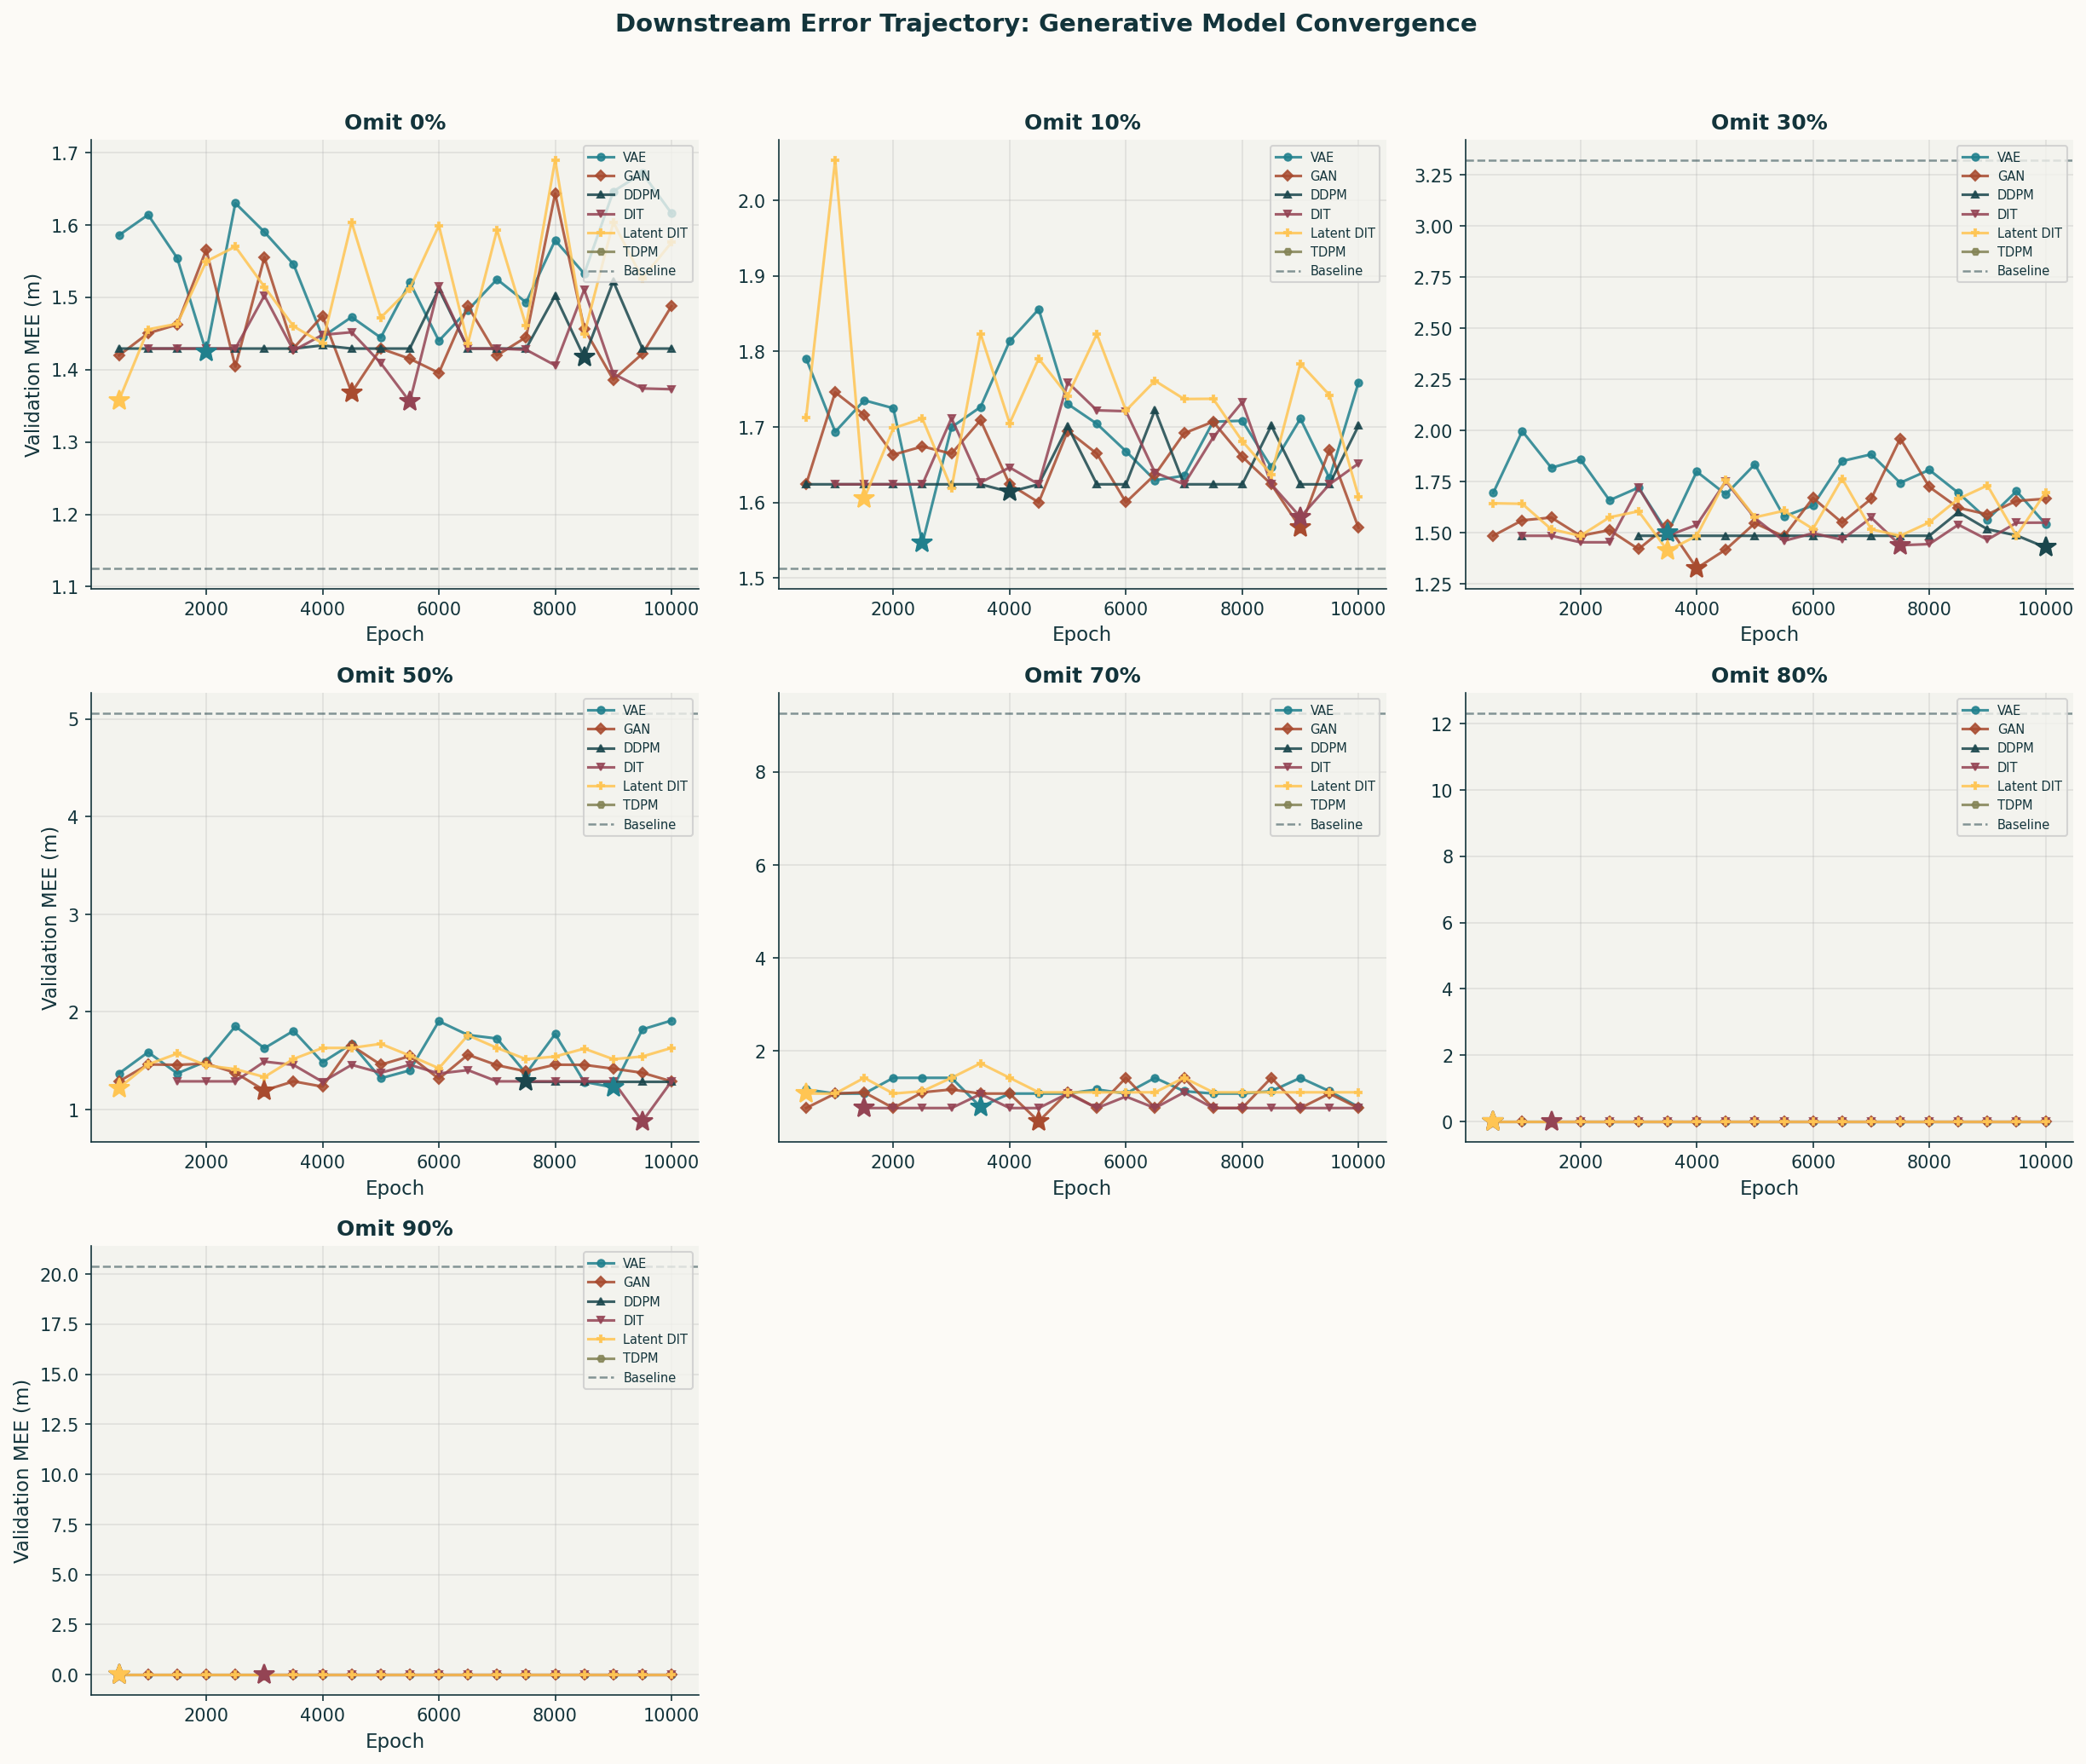

✓ Error trajectory plot saved.


In [ ]:
# Only plot if there are any recorded trajectories
has_trajectories = any(
    pct in HISTORIES[m] and len(HISTORIES[m][pct].get("epochs", [])) > 0
    for m in GEN_METHODS for pct in OMISSION_PCTS
)

if has_trajectories:
    n_traj_levels = len(OMISSION_PCTS)
    n_tcols = min(3, n_traj_levels)
    n_trows = int(np.ceil(n_traj_levels / n_tcols))

    fig, axes = plt.subplots(n_trows, n_tcols,
                             figsize=(5.5 * n_tcols, 4.5 * n_trows),
                             sharey=False)
    if n_traj_levels == 1:
        axes = np.array([axes])
    axes_flat = axes.flatten()

    for idx, pct in enumerate(OMISSION_PCTS):
        ax = axes_flat[idx]
        plotted_any = False
        for method in GEN_METHODS:
            if pct in HISTORIES[method]:
                h = HISTORIES[method][pct]
                if h["epochs"] and len(h["errors"]) > 0:
                    ax.plot(h["epochs"], h["errors"],
                            color=METHOD_COLORS[method],
                            marker=METHOD_MARKERS[method],
                            markersize=4, linewidth=1.5,
                            label=method, alpha=0.85)
                    # Mark best epoch with a star
                    best_idx = int(np.argmin(h["errors"]))
                    ax.plot(h["epochs"][best_idx], h["errors"][best_idx],
                            marker="*", color=METHOD_COLORS[method],
                            markersize=12, zorder=5)
                    plotted_any = True

        # Add baseline reference line
        if pct in RESULTS["Baseline"]:
            ax.axhline(RESULTS["Baseline"][pct]["mee"], color=C["offblack"],
                       linestyle="--", linewidth=1.2, alpha=0.5, label="Baseline")

        ax.set_title(f"Omit {pct}%", fontsize=12)
        ax.set_xlabel("Epoch")
        if idx % n_tcols == 0:
            ax.set_ylabel("Validation MEE (m)")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(True, alpha=0.3)
        if plotted_any:
            ax.legend(fontsize=7, loc="upper right", frameon=True)

    # Hide unused subplots
    for j in range(idx + 1, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle("Downstream Error Trajectory: Generative Model Convergence",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("rescue_trajectories.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Error trajectory plot saved.")
else:
    print("⚠ No error trajectories recorded (validation hook did not fire). Skipping Plot 4.")

## 12c — Plot 5: Floorplan Scatter (Real vs. Synthetic Spatial Coverage)

For each generative model at each sparsity level, scatter the pseudo-labelled
synthetic (x, y) positions alongside the real training positions. This reveals
whether synthetic data fills the spatial gaps left by omission.

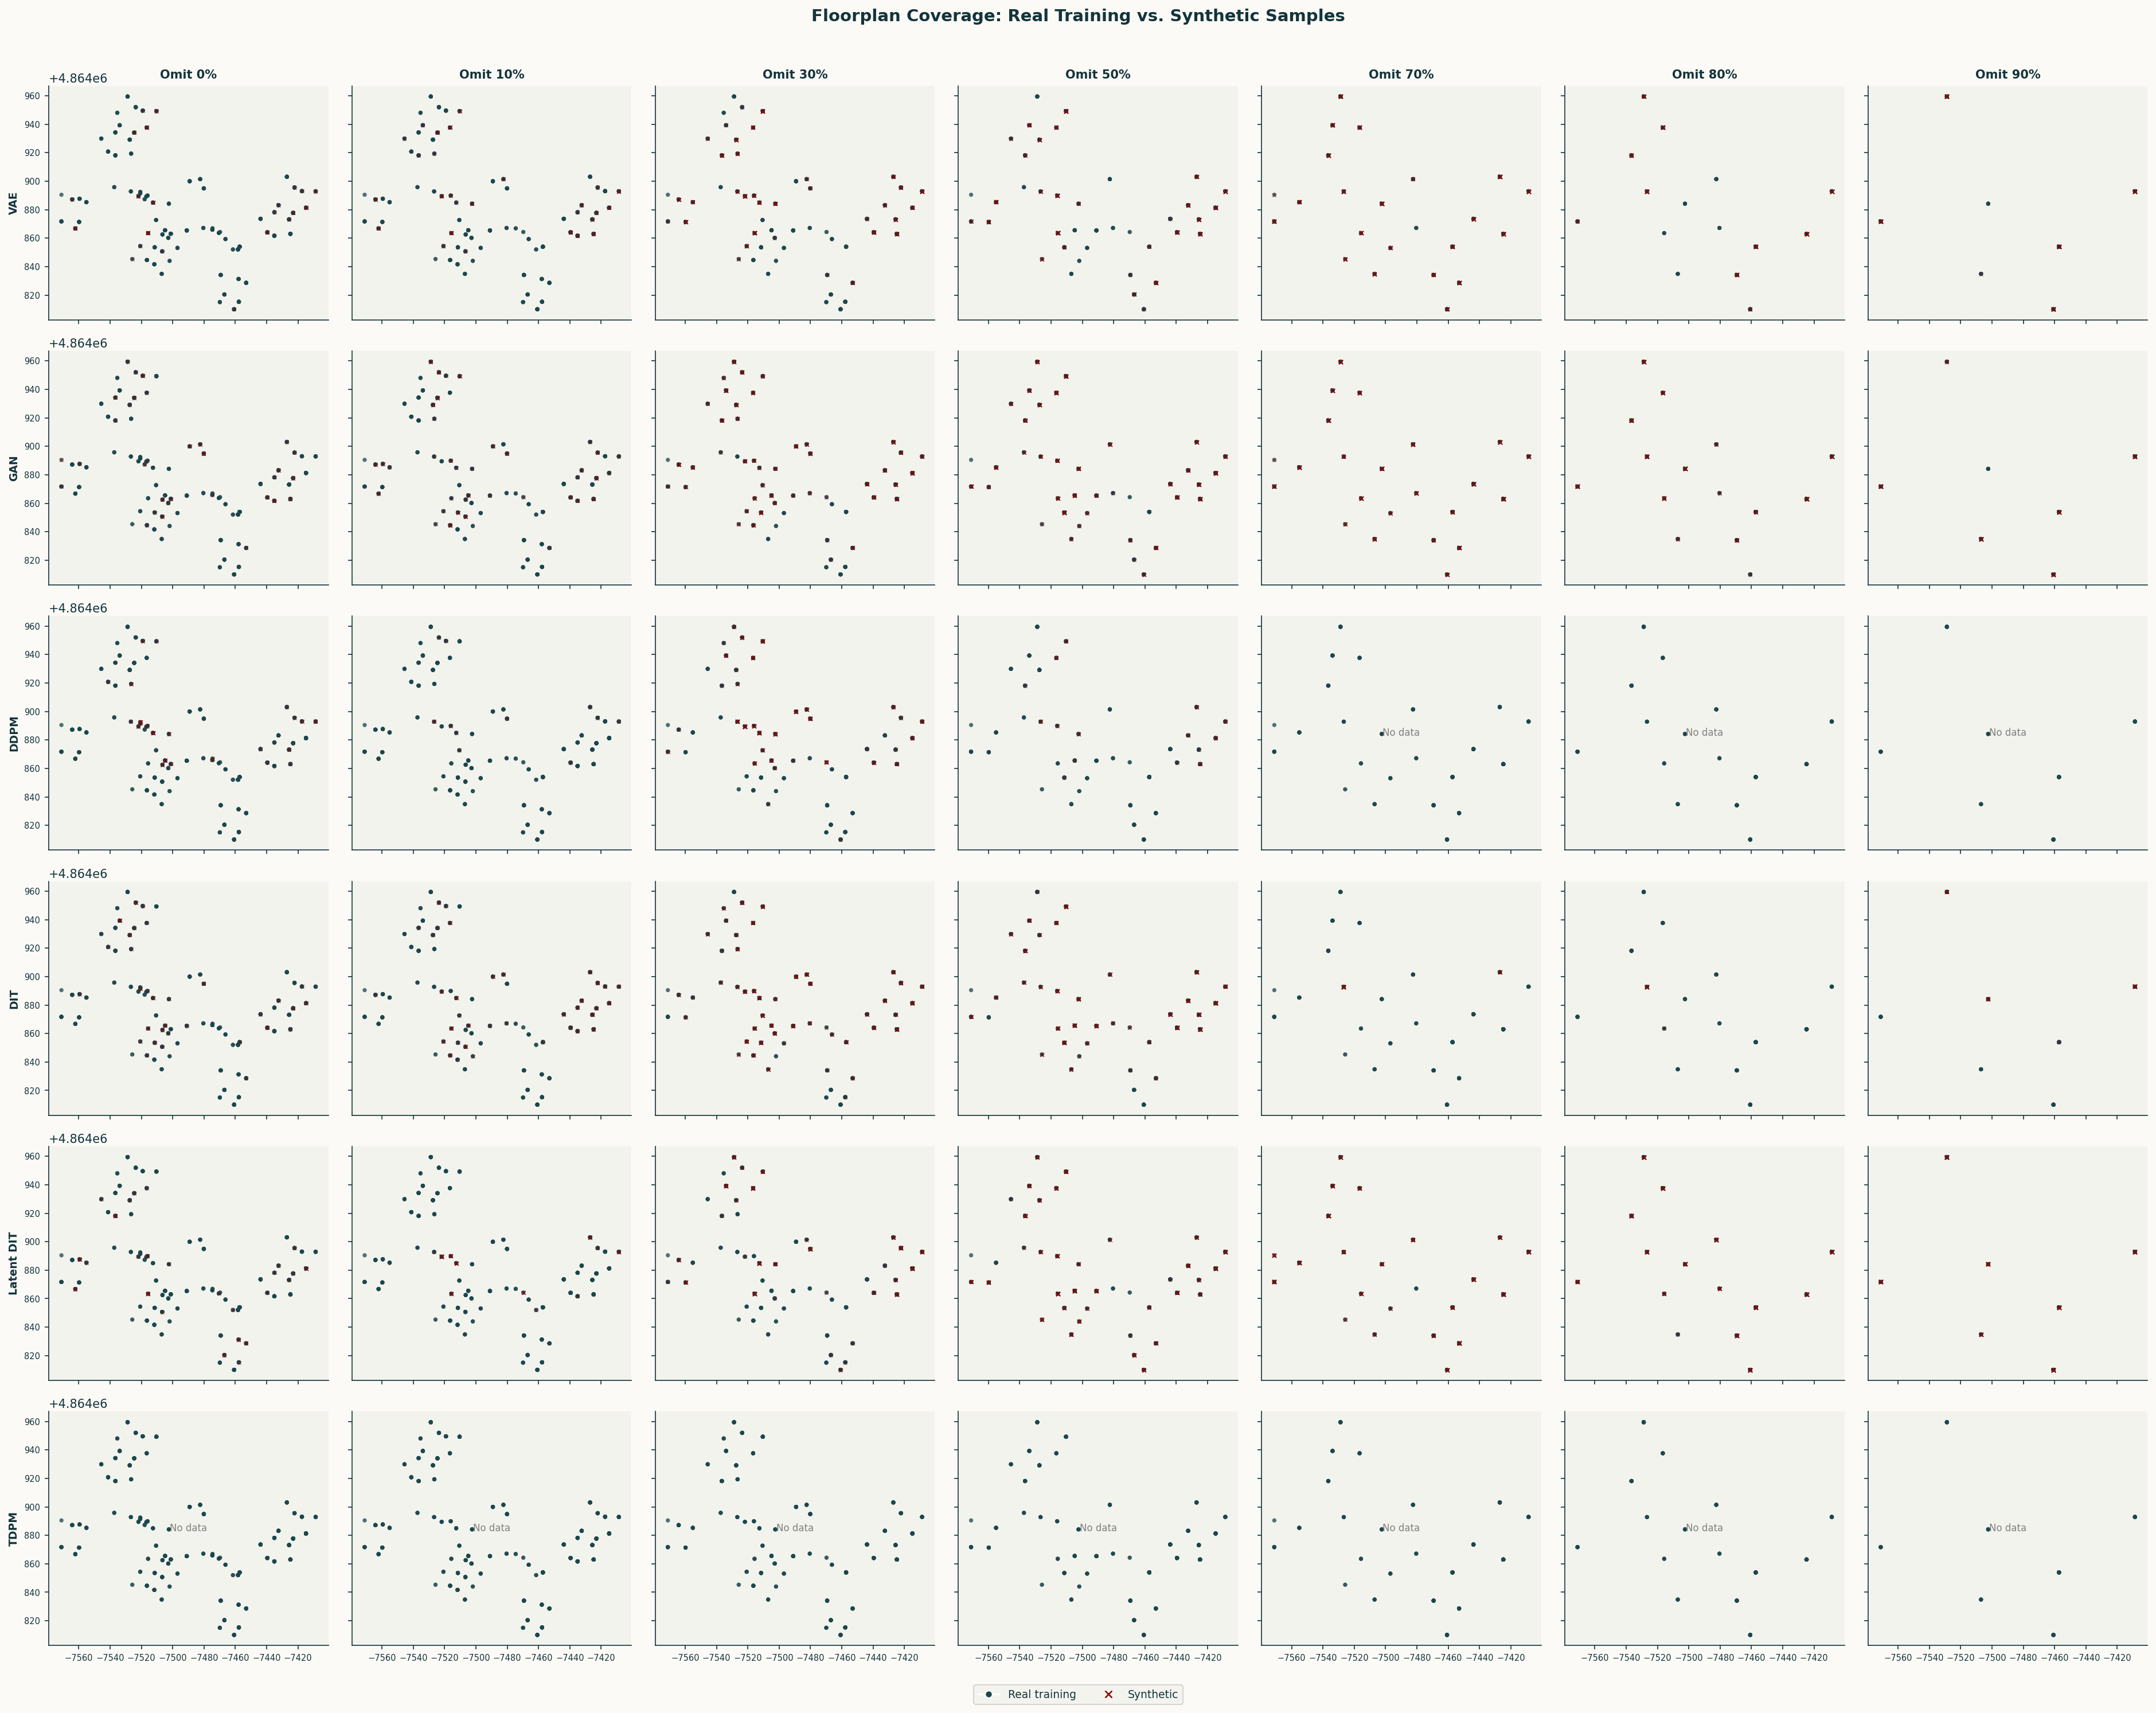

✓ Floorplan scatter plot saved.


In [ ]:
has_synth = any(
    pct in SYNTH_DATA[m] for m in GEN_METHODS for pct in OMISSION_PCTS
)

if has_synth:
    n_rows_fp = len(GEN_METHODS)
    n_cols_fp = len(OMISSION_PCTS)
    fig, axes = plt.subplots(n_rows_fp, n_cols_fp,
                             figsize=(3.6 * n_cols_fp, 3.2 * n_rows_fp),
                             sharex=True, sharey=True)

    for ri, method in enumerate(GEN_METHODS):
        for ci, pct in enumerate(OMISSION_PCTS):
            ax = axes[ri, ci]

            # Plot real training points
            if pct in REAL_DATA_PER_LEVEL:
                rl = REAL_DATA_PER_LEVEL[pct]
                ax.scatter(rl["y_train_raw"][:, 0], rl["y_train_raw"][:, 1],
                           s=12, alpha=0.5, color=C["dark_teal"], label="Real",
                           edgecolors="none", zorder=2)

            # Plot synthetic points
            if pct in SYNTH_DATA[method]:
                sd = SYNTH_DATA[method][pct]
                ax.scatter(sd["pseudo_xy"][:, 0], sd["pseudo_xy"][:, 1],
                           s=10, alpha=0.45, color="#8B0000",
                           marker="x", linewidths=0.7, label="Synthetic", zorder=3)
            else:
                ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                        ha="center", va="center", fontsize=8, color="gray")

            # Labels
            if ri == 0:
                ax.set_title(f"Omit {pct}%", fontsize=10)
            if ci == 0:
                ax.set_ylabel(method, fontsize=9, fontweight="bold")
            ax.tick_params(labelsize=7)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    # Shared legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=C["dark_teal"],
               markersize=6, label="Real training"),
        Line2D([0], [0], marker="x", color="#8B0000", markeredgewidth=1.2,
               markersize=6, linestyle="None", label="Synthetic"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
              fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))

    fig.suptitle("Floorplan Coverage: Real Training vs. Synthetic Samples",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig("synth_floorplan_scatter.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Floorplan scatter plot saved.")
else:
    print("⚠ No synthetic data stored. Skipping floorplan scatter.")

## 12d — Plot 6: RSSI Activation Heatmap (Real vs. Synthetic)

Side-by-side heatmaps comparing the RSSI activation pattern (samples × APs)
of real training data vs. filtered synthetic data. Shows whether generative
models reproduce realistic AP activation patterns.

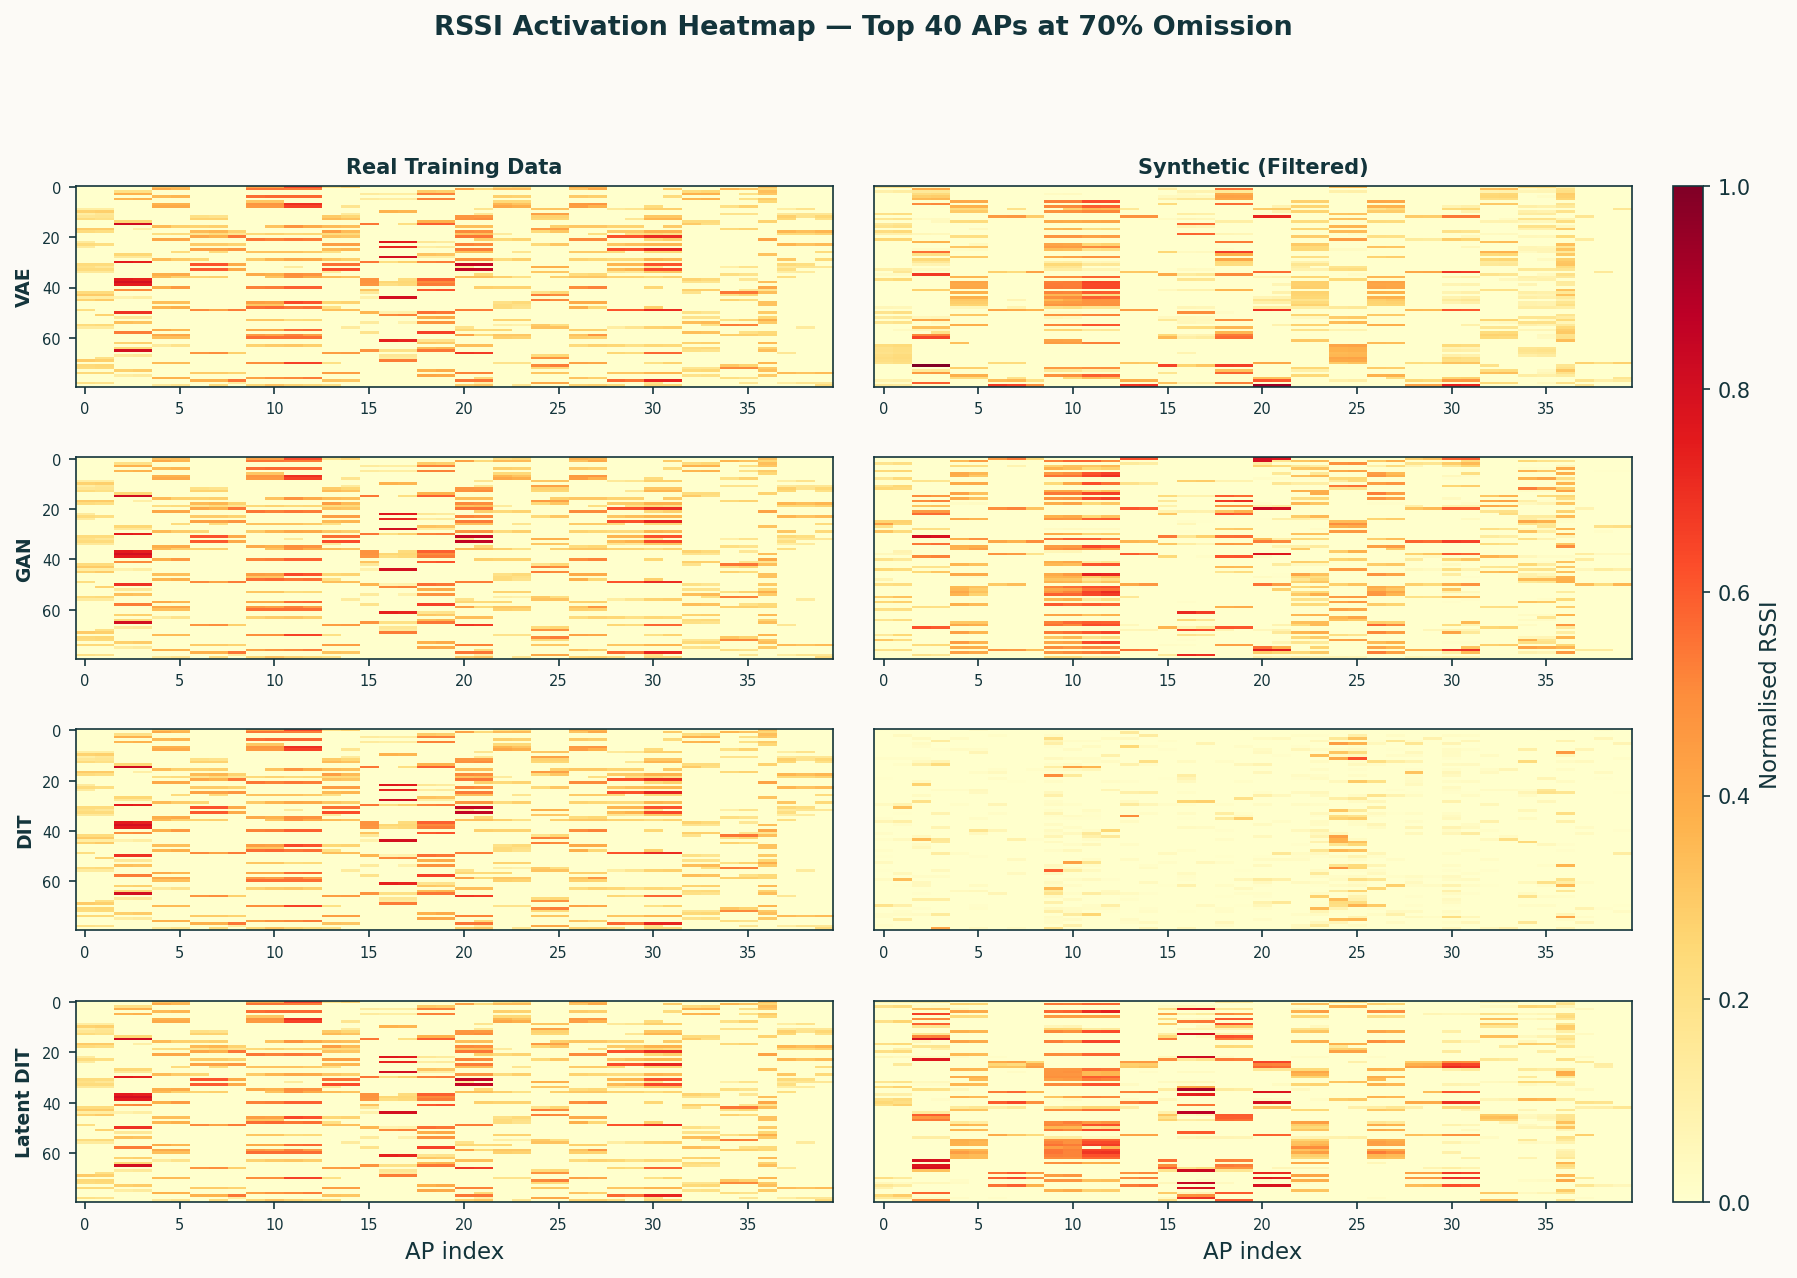

✓ RSSI activation heatmap saved.


In [ ]:
if has_synth:
    # Pick a representative sparsity level for detailed heatmaps.
    # Prefer 70% (medium-high sparsity with enough data); fall back to first available.
    heatmap_pct = None
    for candidate in [70, 50, 80, 30, 90]:
        if candidate in OMISSION_PCTS and any(
            candidate in SYNTH_DATA[m] for m in GEN_METHODS
        ):
            heatmap_pct = candidate
            break

    if heatmap_pct is not None:
        # Collect models that have data at this level
        models_with_data = [m for m in GEN_METHODS if heatmap_pct in SYNTH_DATA[m]]
        n_models_hm = len(models_with_data)

        # Use GridSpec with an extra narrow column for the colorbar
        from matplotlib.gridspec import GridSpec
        fig = plt.figure(figsize=(14, 2.2 * n_models_hm))
        gs = GridSpec(n_models_hm, 3, figure=fig,
                      width_ratios=[1, 1, 0.04], wspace=0.08, hspace=0.35)

        axes = [[fig.add_subplot(gs[r, c]) for c in range(2)]
                for r in range(n_models_hm)]

        rl = REAL_DATA_PER_LEVEL[heatmap_pct]
        # Select a subset of APs that are most active in the real data
        ap_activity = (rl["X_train"] > 0.01).mean(axis=0)
        top_aps = np.argsort(ap_activity)[-40:]  # top 40 most active APs
        top_aps = np.sort(top_aps)

        # Subsample rows for readability
        max_rows = 80
        real_sub = rl["X_train"][:max_rows, :][:, top_aps]

        im_last = None
        for ri, method in enumerate(models_with_data):
            sd = SYNTH_DATA[method][heatmap_pct]
            synth_sub = sd["fake_rssi"][:max_rows, :][:, top_aps]

            # Real
            ax_r = axes[ri][0]
            im_r = ax_r.imshow(real_sub, aspect="auto", cmap="YlOrRd",
                               vmin=0, vmax=1, interpolation="nearest")
            ax_r.set_ylabel(method, fontsize=9, fontweight="bold")
            if ri == 0:
                ax_r.set_title("Real Training Data", fontsize=10)
            ax_r.set_xlabel("AP index" if ri == n_models_hm - 1 else "")
            ax_r.tick_params(labelsize=7)

            # Synthetic
            ax_s = axes[ri][1]
            im_s = ax_s.imshow(synth_sub, aspect="auto", cmap="YlOrRd",
                               vmin=0, vmax=1, interpolation="nearest")
            if ri == 0:
                ax_s.set_title("Synthetic (Filtered)", fontsize=10)
            ax_s.set_xlabel("AP index" if ri == n_models_hm - 1 else "")
            ax_s.tick_params(labelsize=7)
            ax_s.set_yticks([])
            im_last = im_s

        # Colorbar in dedicated axis on the right
        cbar_ax = fig.add_subplot(gs[:, 2])
        fig.colorbar(im_last, cax=cbar_ax, label="Normalised RSSI")

        fig.suptitle(f"RSSI Activation Heatmap — Top 40 APs at {heatmap_pct}% Omission",
                     fontsize=13, fontweight="bold", y=1.01)
        plt.savefig("synth_rssi_heatmap.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("✓ RSSI activation heatmap saved.")
    else:
        print("⚠ No suitable sparsity level for RSSI heatmap.")
else:
    print("⚠ No synthetic data stored. Skipping RSSI heatmap.")


## 12e — Plot 7: Distribution Comparison (RSSI Value & Active AP Count)

For each model at each sparsity level, overlay KDE curves comparing:
- (Left) Distribution of non-zero RSSI values: real vs. synthetic
- (Right) Distribution of the number of active APs per sample

In [ ]:
if has_synth:
    n_rows_dist = len(GEN_METHODS)
    n_cols_dist = len(OMISSION_PCTS)

    # ── Sub-plot A: RSSI value distribution ──────────────────────────
    fig, axes = plt.subplots(n_rows_dist, n_cols_dist,
                             figsize=(3.4 * n_cols_dist, 2.6 * n_rows_dist),
                             sharex=True, sharey=True)

    for ri, method in enumerate(GEN_METHODS):
        for ci, pct in enumerate(OMISSION_PCTS):
            ax = axes[ri, ci]

            if pct in REAL_DATA_PER_LEVEL:
                real_vals = REAL_DATA_PER_LEVEL[pct]["X_train"].ravel()
                real_nonzero = real_vals[real_vals > 0.01]
                ax.hist(real_nonzero, bins=40, density=True, alpha=0.45,
                        color=C["dark_teal"], label="Real", edgecolor="none")

            if pct in SYNTH_DATA[method]:
                synth_vals = SYNTH_DATA[method][pct]["fake_rssi"].ravel()
                synth_nonzero = synth_vals[synth_vals > 0.01]
                ax.hist(synth_nonzero, bins=40, density=True, alpha=0.45,
                        color=METHOD_COLORS[method], label="Synth", edgecolor="none")

            if ri == 0:
                ax.set_title(f"Omit {pct}%", fontsize=9)
            if ci == 0:
                ax.set_ylabel(method, fontsize=8, fontweight="bold")
            ax.tick_params(labelsize=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fig.suptitle("RSSI Value Distribution: Real vs. Synthetic (non-zero values)",
                 fontsize=13, fontweight="bold", y=1.01)
    # Shared legend
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, fc=C["dark_teal"], alpha=0.5, label="Real"),
        plt.Rectangle((0, 0), 1, 1, fc=C["teal"], alpha=0.5, label="Synthetic"),
    ]
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
              fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig("synth_rssi_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ RSSI value distribution plot saved.")

    # ── Sub-plot B: Active AP count distribution ─────────────────────
    fig, axes = plt.subplots(n_rows_dist, n_cols_dist,
                             figsize=(3.4 * n_cols_dist, 2.6 * n_rows_dist),
                             sharex=True, sharey=True)

    for ri, method in enumerate(GEN_METHODS):
        for ci, pct in enumerate(OMISSION_PCTS):
            ax = axes[ri, ci]

            if pct in REAL_DATA_PER_LEVEL:
                real_counts = (REAL_DATA_PER_LEVEL[pct]["X_train"] > 0.01).sum(axis=1)
                ax.hist(real_counts, bins=range(0, int(real_counts.max()) + 2),
                        density=True, alpha=0.45, color=C["dark_teal"],
                        label="Real", edgecolor="none")

            if pct in SYNTH_DATA[method]:
                synth_counts = (SYNTH_DATA[method][pct]["fake_rssi"] > 0.01).sum(axis=1)
                ax.hist(synth_counts,
                        bins=range(0, int(max(synth_counts.max(), 1)) + 2),
                        density=True, alpha=0.45, color=METHOD_COLORS[method],
                        label="Synth", edgecolor="none")

            if ri == 0:
                ax.set_title(f"Omit {pct}%", fontsize=9)
            if ci == 0:
                ax.set_ylabel(method, fontsize=8, fontweight="bold")
            ax.tick_params(labelsize=6)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

    fig.suptitle("Active AP Count Distribution: Real vs. Synthetic",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.legend(handles=legend_elements, loc="lower center", ncol=2,
              fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.02))
    plt.tight_layout()
    plt.savefig("synth_active_ap_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✓ Active AP count distribution plot saved.")
else:
    print("⚠ No synthetic data stored. Skipping distribution plots.")

## 13 — Plot 8: CDF Error Curves

Cumulative Distribution Function of per-sample localization error for
every model at each sparsity level.  One subplot per omission rate.
The CDF shows what fraction of test samples are localized within a
given distance threshold — a standard evaluation metric for indoor
positioning systems.

In [ ]:
print("\n── Generating CDF Error Curve plots...")

n_cdf_levels = len(OMISSION_PCTS)
n_cdf_cols = min(3, n_cdf_levels)
n_cdf_rows = int(np.ceil(n_cdf_levels / n_cdf_cols))

fig_cdf, axes_cdf = plt.subplots(
    n_cdf_rows, n_cdf_cols,
    figsize=(6.0 * n_cdf_cols, 5.0 * n_cdf_rows),
    sharey=True,
)
if n_cdf_levels == 1:
    axes_cdf = np.array([axes_cdf])
axes_cdf_flat = axes_cdf.flatten()

all_methods_cdf = ["Baseline"] + GEN_METHODS

for idx, pct in enumerate(OMISSION_PCTS):
    ax = axes_cdf_flat[idx]
    for method in all_methods_cdf:
        if pct not in RESULTS[method]:
            continue
        dists = RESULTS[method][pct].get("dists")
        if dists is None:
            continue
        sorted_d = np.sort(dists)
        cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)

        ls = "--" if method == "Baseline" else "-"
        lw = 2.5 if method == "Baseline" else 1.8
        ax.plot(sorted_d, cdf, ls,
                color=METHOD_COLORS[method],
                linewidth=lw, label=method, alpha=0.9)

    ax.set_title(f"Omit {pct}%", fontsize=12)
    ax.set_xlabel("Localization Error (m)")
    if idx % n_cdf_cols == 0:
        ax.set_ylabel("CDF")
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.axhline(0.5, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.axhline(0.9, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=7.5, loc="lower right", frameon=True, framealpha=0.85)

# Hide unused subplots
for j in range(idx + 1, len(axes_cdf_flat)):
    axes_cdf_flat[j].set_visible(False)

fig_cdf.suptitle(
    "CDF of Localization Error: All Models Under Spatial Sparsity",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("cdf_error_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ CDF error curves saved to cdf_error_curves.png")

# ── Also produce a single combined CDF panel showing all sparsity levels ──
# One subplot per model, each subplot overlays CDF curves for all sparsity levels.

n_models_all = len(all_methods_cdf)
n_comb_cols = min(4, n_models_all)
n_comb_rows = int(np.ceil(n_models_all / n_comb_cols))

SPARSITY_COLORS = {
    30: "#2ecc71",   # green (mild)
    50: "#3498db",   # blue
    70: "#f39c12",   # orange
    80: "#e74c3c",   # red
    90: "#8e44ad",   # purple (extreme)
}

fig_comb, axes_comb = plt.subplots(
    n_comb_rows, n_comb_cols,
    figsize=(5.5 * n_comb_cols, 4.5 * n_comb_rows),
    sharey=True, sharex=True,
)
if n_models_all == 1:
    axes_comb = np.array([axes_comb])
axes_comb_flat = axes_comb.flatten()

for mi, method in enumerate(all_methods_cdf):
    ax = axes_comb_flat[mi]
    for pct in OMISSION_PCTS:
        if pct not in RESULTS[method]:
            continue
        dists = RESULTS[method][pct].get("dists")
        if dists is None:
            continue
        sorted_d = np.sort(dists)
        cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
        ax.plot(sorted_d, cdf,
                color=SPARSITY_COLORS.get(pct, "gray"),
                linewidth=1.8, label=f"{pct}%", alpha=0.9)

    ax.set_title(method, fontsize=11, fontweight="bold")
    ax.set_xlabel("Error (m)")
    if mi % n_comb_cols == 0:
        ax.set_ylabel("CDF")
    ax.set_ylim(0, 1.02)
    ax.set_xlim(left=0)
    ax.axhline(0.5, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.axhline(0.9, color="gray", linewidth=0.6, linestyle=":", alpha=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=8, loc="lower right", frameon=True,
              framealpha=0.85, title="Omit %", title_fontsize=8)

for j in range(mi + 1, len(axes_comb_flat)):
    axes_comb_flat[j].set_visible(False)

fig_comb.suptitle(
    "CDF of Localization Error: Per-Model Across Sparsity Levels",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig("cdf_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Per-model CDF curves saved to cdf_per_model.png")

## 14 — Summary & Analysis

In [ ]:
print("\n" + "═" * 70)
print("  FINAL SUMMARY: Generative Sparsity Rescue Results")
print("═" * 70)

# Pivot table: Method × Omission %
pivot_rows = []
for method in ["Baseline"] + GEN_METHODS:
    row = {"Method": method}
    for pct in OMISSION_PCTS:
        if pct in RESULTS[method]:
            row[f"{pct}%"] = round(RESULTS[method][pct]["mee"], 2)
        else:
            row[f"{pct}%"] = "—"
    pivot_rows.append(row)

pivot_df = pd.DataFrame(pivot_rows)
print("\nMEE (m) by Method and Omission Rate:")
print(pivot_df.to_markdown(index=False))

# Best method per omission level
print("\nBest Method per Sparsity Level:")
for pct in OMISSION_PCTS:
    all_mees = {}
    for method in ["Baseline"] + GEN_METHODS:
        if pct in RESULTS[method]:
            all_mees[method] = RESULTS[method][pct]["mee"]
    if all_mees:
        best = min(all_mees, key=all_mees.get)
        baseline_mee = all_mees.get("Baseline", float("inf"))
        best_mee = all_mees[best]
        improvement = (baseline_mee - best_mee) / baseline_mee * 100
        print(f"  {pct}%: {best} = {best_mee:.2f} m "
              f"({'baseline' if best == 'Baseline' else f'{improvement:.1f}% improvement'})")

print("\n✓ All results saved and plots generated.")